# 03 Modelado - Dengue Magdalena

Este notebook construye y compara modelos de pronostico de casos de dengue para el departamento del Magdalena, a partir del dataset semanal generado en el notebook 02 (dataset_modelado_magdalena.parquet), que combina los casos confirmados de SIVIGILA con las variables climáticas de la fuente ganadora por variable.

El flujo es el siguiente:

1. Carga del dataset.
2. Análisis de la serie: visualización, transformación, descomposición, estacionariedad y autocorrelación.
3. División temporal train / test.
4. Modelos estadísticos: ARIMA, SARIMA, SARIMAX y Prophet.
5. Gradient Boosting: ingeniería de características, XGBoost y LightGBM.
6. LSTM.
7. Comparación de todos los modelos.
8. Interpretabilidad con SHAP.

# 1 Carga del dataset

In [128]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

from prophet import Prophet

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, PowerTransformer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import mlflow
import shap

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUTS = PROJECT_ROOT / 'outputs' / 'figures' / 'model'
OUTPUTS.mkdir(exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT / 'mlruns' / 'mlflow.db'}")
mlflow.set_experiment('dengue-magdalena')

df = pd.read_parquet(DATA_DIR / 'processed' / 'dataset_modelado_magdalena.parquet')
print(f'Shape: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
print(f'Anios: {sorted(df["anio_epi"].unique())}')
print(f'Municipios: {df["municipio"].nunique()}')
df.head()


Shape: (9420, 10)
Columnas: ['municipio', 'fecha_semana', 'anio_epi', 'semana_epi', 'casos', 'humedad', 'precipitacion', 't2m_max', 't2m_media', 't2m_min']
Anios: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Municipios: 30


,municipio,fecha_semana,anio_epi,semana_epi,casos,humedad,precipitacion,t2m_max,t2m_media,t2m_min
0,ALGARROBO,2018-12-30,2019,1,4,41.749115,0.000000,38.745502,30.646749,22.815500
1,ALGARROBO,2019-01-06,2019,2,1,54.897469,12.724156,35.446930,29.124311,23.996929
2,ALGARROBO,2019-01-13,2019,3,2,48.087048,0.000000,37.275501,30.023119,23.911215
3,ALGARROBO,2019-01-20,2019,4,4,45.644573,0.000000,38.654072,30.907347,24.018358
4,ALGARROBO,2019-01-27,2019,5,2,53.694569,0.000000,36.782646,30.166870,24.732645


In [129]:
def compute_metrics(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.any() else float('nan')
    return {
        'RMSE': round(rmse, 3),
        'MAE':  round(mae, 3),
        'MAPE': round(mape, 2),
        'R2':   round(r2, 4),
    }

def print_metrics(nombre, m):
    print(f'{nombre:35s} RMSE={m["RMSE"]:7.2f} | MAE={m["MAE"]:6.2f} | MAPE={m["MAPE"]:6.2f}% | R2={m["R2"]:6.4f}')

In [130]:
clima = ['humedad', 'precipitacion', 't2m_max', 't2m_media', 't2m_min']

df_dep = (
    df.groupby('fecha_semana')
    .agg({'casos': 'sum', **{v: 'mean' for v in clima}})
    .reset_index()
    .rename(columns={'fecha_semana': 'fecha'})
    .sort_values('fecha')
    .reset_index(drop=True)
)

print(f'Serie departamental: {len(df_dep)} semanas')
print(f'Periodo: {df_dep["fecha"].min().date()} -> {df_dep["fecha"].max().date()}')
print(f'Total casos: {df_dep["casos"].sum():,}')
df_dep.head()


Serie departamental: 314 semanas
Periodo: 2018-12-30 -> 2024-12-29
Total casos: 13,128


,fecha,casos,humedad,precipitacion,t2m_max,t2m_media,t2m_min
0,2018-12-30,72,59.782101,0.000000,36.049767,29.662600,24.225100
1,2019-01-06,118,71.482460,7.069436,33.314053,28.350630,24.507147
2,2019-01-13,132,66.488258,1.137560,34.839054,29.224749,24.929529
3,2019-01-20,123,62.743526,1.378456,36.077385,29.953932,25.300482
4,2019-01-27,104,68.154648,1.710686,34.513813,29.310251,25.371910


# 2 Análisis de la serie de tiempo

Antes de modelar se estudia la estructura de la serie de casos. Primero se visualiza la serie, luego se evalua la necesidad de estabilizar su varianza, posteriorormente se descompone la serie para evaluar la estacionalidad de la serie, luego evaluamos la estacionariedad para considerar si es necesario una diferenciacion y por ultimo miramos la autocorrelación de la serie

## 2.1 Visualización de la serie original

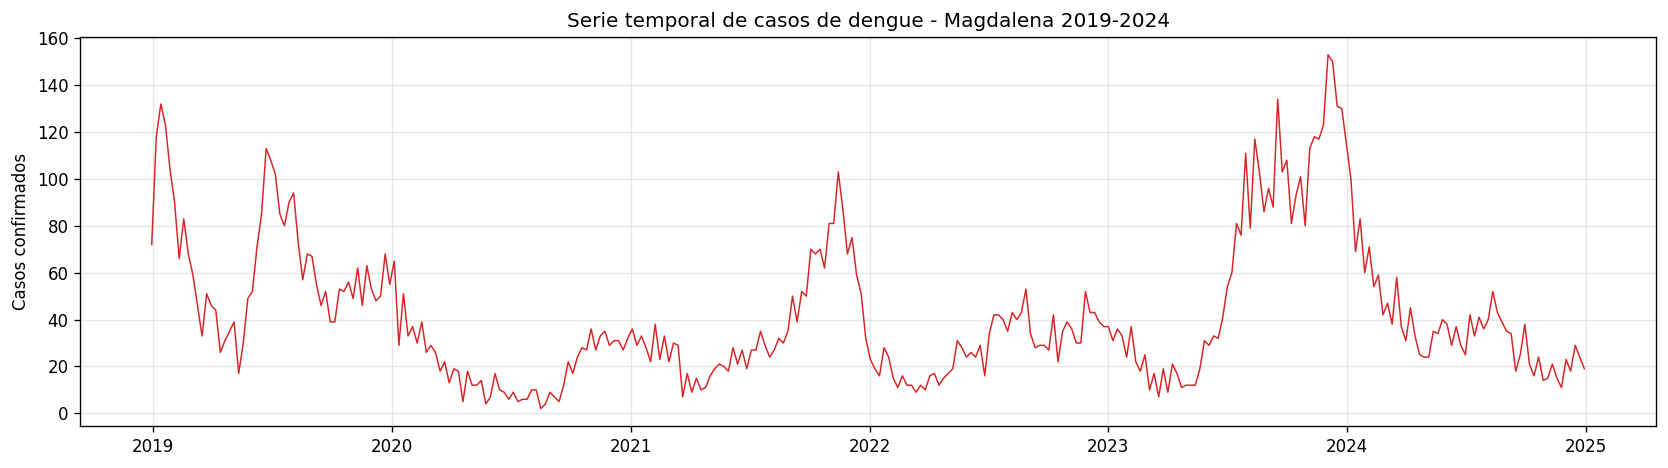

In [131]:
serie = df_dep.set_index('fecha')['casos']


fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(serie.index, serie.values, color='#d62728', linewidth=0.9) #type: ignore
ax.set_ylabel('Casos confirmados')
ax.set_title('Serie temporal de casos de dengue - Magdalena 2019-2024')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'serie_casos.png', dpi=150, bbox_inches='tight')
plt.show()

La serie muestra una estacionalidad anual marcada, con un pico de transmisión cada año, y una variabilidad fuerte en la intensidad de esos picos: el brote de 2024 supera los 150 casos semanales. Entre temporadas altas se observan períodos de baja transmisión con valores cercanos a cero por lo que porcederemos a estabilizar su varianza

## 2.2 Estabilidad de varianza con transformación log1p

Muchos modelos estadísticos asumen varianza constante (homocedasticidad); si la varianza crece junto con el nivel de casos, esa suposición se rompe. Primero se revisa la varianza móvil sobre una ventana de 12 semanas (un trimestre): si crece en los períodos de brote, hay heterocedasticidad. Luego se aplica la transformación log(1+x) (se usa 1+x porque la serie tiene semanas con cero casos) y se compara la estabilidad del coeficiente de variación móvil de ambas series para confirmar la mejora. El análisis de las secciones siguientes se hace sobre la serie ya transformada.

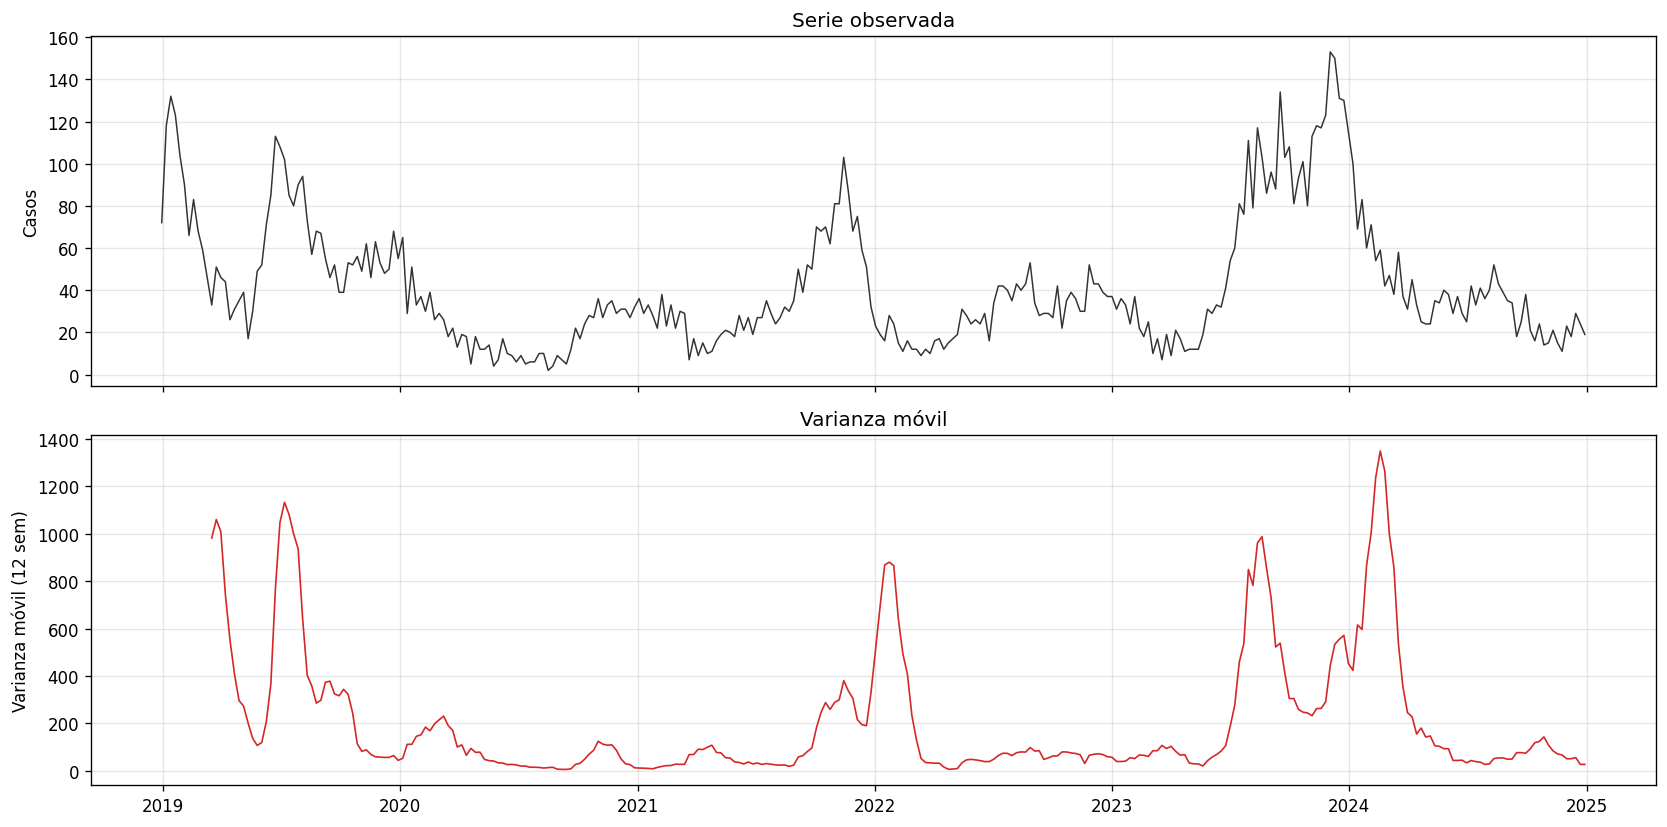

Varianza móvil mínima: 6.3
Varianza móvil máxima: 1348.3
Razón máx/mín: 215.2


In [133]:
VENTANA = 12 
var_movil = serie.rolling(window=VENTANA).var()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(serie.index, serie.values, color='#333333', linewidth=0.9)
axes[0].set_ylabel('Casos')
axes[0].set_title('Serie observada')
axes[0].grid(alpha=0.3)

axes[1].plot(var_movil.index, var_movil.values, color='#d62728', linewidth=1.0)
axes[1].set_ylabel(f'Varianza móvil ({VENTANA} sem)')
axes[1].set_title('Varianza móvil')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'varianza_movil.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Varianza móvil mínima: {var_movil.min():.1f}')
print(f'Varianza móvil máxima: {var_movil.max():.1f}')
print(f'Razón máx/mín: {var_movil.max() / var_movil.min():.1f}')

La varianza móvil está lejos de ser constante, se dispara durante los brotes de mitad de año 2019, principios 2022, mitad de año 2023 y principios de 2024, cae casi a cero en los períodos de baja transmisión. La razón entre la varianza máxima y mínima supera ampliamente un orden de magnitud, lo que confirma que la serie es fuertemente heterocedástica: la dispersión crece con el nivel de casos. Esto viola el supuesto de varianza constante de los modelos estadísticos y justifica evaluar una transformación estabilizadora en la sección siguiente.

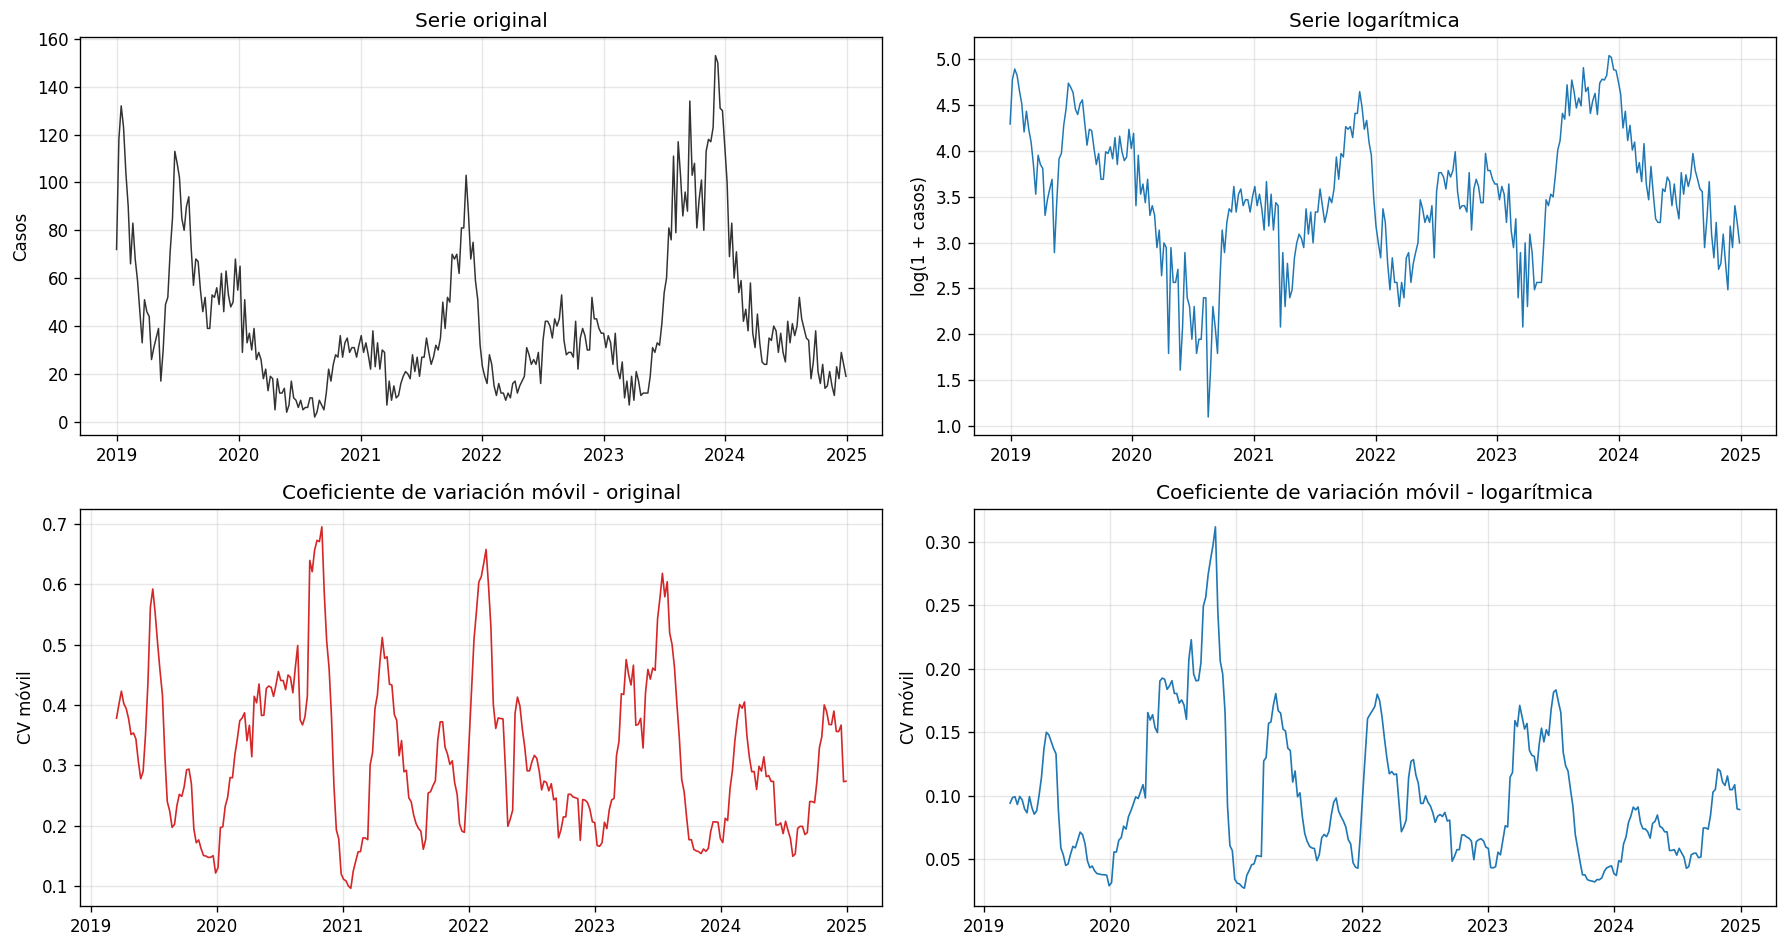

Varianza del CV móvil - original: 0.016314
Varianza del CV móvil - log: 0.002875
Reducción: 82%


In [135]:
serie_log = np.log1p(serie)

# Coeficiente de variacion movil: dispersion relativa a la media en cada ventana
def cv_movil(s, v=VENTANA):
    return (s.rolling(v).std() / s.rolling(v).mean()).dropna()

cv_orig = cv_movil(serie)
cv_log = cv_movil(serie_log)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# Fila 1: serie original y serie logaritmica
axes[0, 0].plot(serie.index, serie.values, color='#333333', linewidth=0.9)
axes[0, 0].set_ylabel('Casos')
axes[0, 0].set_title('Serie original')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(serie_log.index, serie_log.values, color='#1f77b4', linewidth=0.9)
axes[0, 1].set_ylabel('log(1 + casos)')
axes[0, 1].set_title('Serie logarítmica')
axes[0, 1].grid(alpha=0.3)


# Fila 2: cv movil serie original y cv movil serie original logaritmica
axes[1, 0].plot(cv_orig.index, cv_orig.values, color='#d62728', linewidth=1.0)
axes[1, 0].set_ylabel('CV móvil')
axes[1, 0].set_title('Coeficiente de variación móvil - original')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(cv_log.index, cv_log.values, color='#1f77b4', linewidth=1.0)
axes[1, 1].set_ylabel('CV móvil')
axes[1, 1].set_title('Coeficiente de variación móvil - logarítmica')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS / 'comparacion_cv_movil.png', dpi=150, bbox_inches='tight')
plt.show()


print(f'Varianza del CV móvil - original: {cv_orig.var():.6f}')
print(f'Varianza del CV móvil - log: {cv_log.var():.6f}')
print(f'Reducción: {(1 - cv_log.var() / cv_orig.var()) * 100:.0f}%')

La varianza móvil de la sección anterior confirmó que la dispersión crece con el nivel de casos, pero no se puede usar directamente para comparar la serie original con la serie logarítmica ya que ambas están en escalas distintas (una en casos, la otra en log(1+casos)). Para hacer la comparación justa se usa el coeficiente de variación móvil (CV = desviación estándar / media), que es adimensional y elimina el efecto de la escala al expresar la dispersión como proporción de la media local.

La transformación logarítmica reduce la variabilidad del coeficiente de variación 
móvil respecto a la serie original, confirmando que estabiliza la dispersión. 
Adicionalmente, el patrón cíclico visible en el CV móvil de ambas series, con 
picos que se repiten aproximadamente cada 52 semanas evidencia una estacionalidad 
anual marcada, por lo que en la siguiente sección miraremos los componentes de la serie por separado para evaluar la presencia de estacionalidad.

## 2.3 Descomposición STL sobre la serie logarítmica

Se descompone la serie en tendencia, estacionalidad y ruido para entender su estructura. Conceptualmente una serie combina tendencia (comportamiento de fondo), ciclo (oscilaciones de duración variable), estacionalidad (patrón fijo, anual aquí) y ruido. En la práctica tendencia y ciclo se entregan juntos porque su separación no es identificable de forma única.

Se usa STL (Seasonal-Trend decomposition using Loess), que ajusta curvas locales suaves. Se elige sobre la descomposición clásica porque permite que el patrón estacional evolucione a lo largo de los años y es robusta frente a valores atípicos como los picos de brote. La descomposición se aplica sobre la serie logarítmica, como STL asume un modelo aditivo (Y = tendencia + estacionalidad + ruido) y la serie original es multiplicativa (la amplitud crece con el nivel), el logaritmo convierte esa relación multiplicativa en aditiva y hace válida la descomposición.

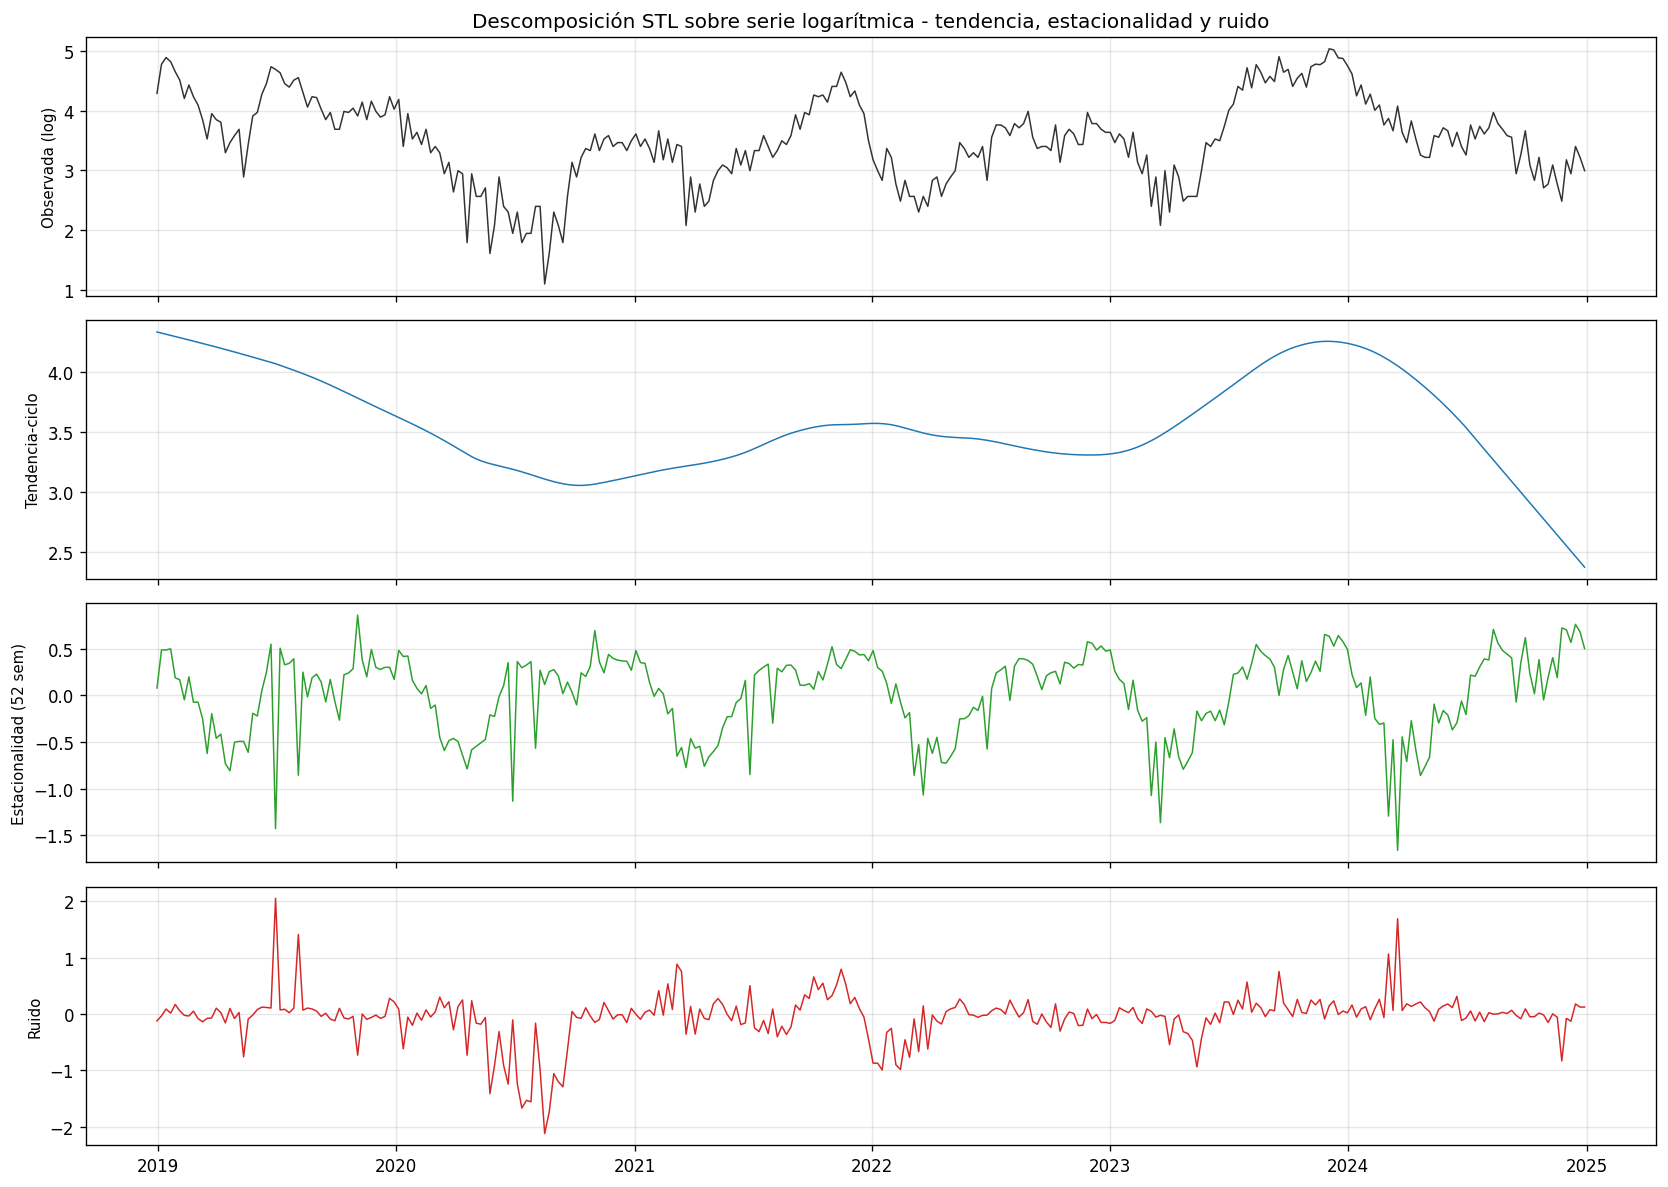

In [137]:
stl = STL(serie_log, period=52, seasonal=13, trend=53, robust=True).fit()
tendencia = stl.trend
estacionalidad = stl.seasonal
ruido = stl.resid

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
componentes = [
    (serie_log, 'Observada (log)', '#333333'),
    (tendencia, 'Tendencia-ciclo', '#1f77b4'),
    (estacionalidad, 'Estacionalidad (52 sem)', '#2ca02c'),
    (ruido, 'Ruido', '#d62728'),
]
for ax, (data, titulo, color) in zip(axes, componentes):
    ax.plot(data.index, data.values, color=color, linewidth=0.9)
    ax.set_ylabel(titulo, fontsize=9)
    ax.grid(alpha=0.3)
axes[0].set_title('Descomposición STL sobre serie logarítmica - tendencia, estacionalidad y ruido')
plt.tight_layout()
plt.savefig(OUTPUTS / 'descomposicion_serie.png', dpi=150, bbox_inches='tight')
plt.show()

La descomposición confirma una estacionalidad anual marcada y estable en su forma, con un ciclo de 52 semanas que se repite cada año, lo que respalda el uso de terminos estacionales en los modelos. El componente de tendencia ciclo muestra un patron multianual coherente con la dinamica epidemica conocida del dengue en Colombia, con picos de transmision alrededor de 2019 y 2023-2024 y un valle marcado hacia 2020-2021, periodo que coincide con la pandemia de COVID y posible subregistro.

El residuo se mantiene en general pequeño y centrado en cero, pero presenta picos puntuales coincidentes con los extremos de la tendencia, lo que sugiere semanas con desviaciones fuertes respecto al patron esperado, ya sea por brotes atipicos o por anomalias de reporte. Tambien vale la pena tener en cuenta que el tramo final de la tendencia muestra una caida pronunciada que podria estar influenciada por el efecto de borde del suavizado loess, dado que en los extremos de la serie hay menos datos disponibles.

Ahora evaluaremos si la serie es estacionaria.

## 2.4 Pruebas de estacionariedad (ADF, KPSS)

Una serie es estacionaria cuando sus propiedades estadísticas (media, varianza, autocorrelación) no cambian con el tiempo. La mayoría de modelos ARIMA exigen estacionariedad, por lo que se verifica y, si no se cumple, se aplica diferenciación.

Se usan dos pruebas complementarias. ADF (Augmented Dickey-Fuller) tiene como hipótesis nula que la serie NO es estacionaria; un p-valor menor a 0.05 permite concluir estacionariedad. KPSS tiene la hipótesis nula contraria; aquí un p-valor menor a 0.05 lleva a rechazar la estacionariedad. La conclusión más confiable se da cuando ambas coinciden. Las pruebas se aplican sobre la serie logarítmica, su diferencia regular y su diferencia estacional, para sustentar la elección de d y D con evidencia. Es importante distinguir estacionariedad de estacionalidad: ADF y KPSS detectan tendencia estocástica pero no miden el patrón estacional.

In [139]:
def run_adf(serie):
    stat, p, _, _, crit, _ = adfuller(serie.dropna(), autolag='AIC')  # type: ignore
    return p, ('Estacionaria' if p < 0.05 else 'No estacionaria')

def run_kpss(serie):
    stat, p, _, crit = kpss(serie.dropna(), regression='c', nlags='auto')
    return p, ('No estacionaria' if p < 0.05 else 'Estacionaria')

def evaluar(serie, nombre):
    p_adf, c_adf = run_adf(serie)
    p_kpss, c_kpss = run_kpss(serie)
    return {
        'Serie': nombre,
        'ADF p-valor': round(p_adf, 4), 'ADF': c_adf,  # type: ignore
        'KPSS p-valor': round(p_kpss, 4), 'KPSS': c_kpss,
        'Estacionaria (ambas)': (c_adf == 'Estacionaria') and (c_kpss == 'Estacionaria'),
    }

# Se evalua la serie log sin diferenciar, con diferencia regular y con diferencia estacional
# para sustentar la eleccion de d y D con evidencia, no a priori.
df_stationarity = pd.DataFrame([
    evaluar(serie_log, 'Log sin diferenciar'),
    evaluar(serie_log.diff(), 'Log diff regular (d=1)'),
    evaluar(serie_log.diff(52), 'Log diff estacional (D=1, s=52)'),
])
print(df_stationarity.to_string(index=False))

                          Serie  ADF p-valor             ADF  KPSS p-valor         KPSS  Estacionaria (ambas)
            Log sin diferenciar       0.0129    Estacionaria        0.1000 Estacionaria                  True
         Log diff regular (d=1)       0.0000    Estacionaria        0.1000 Estacionaria                  True
Log diff estacional (D=1, s=52)       0.2714 No estacionaria        0.0845 Estacionaria                 False


Las pruebas confirman que la serie log es estacionaria sin necesidad de diferenciacion (d=0). Aunque la diferencia regular tambien resulta estacionaria, aplicarla seria innecesario y conlleva riesgo de sobre-diferenciacion. La diferencia estacional (D=1, s=52) se evalua porque la estacionalidad anual es evidente en la serie visualmente en la descomposicion STL, y antes de decidir como modelarla es necesario comprobar si diferenciar estacionalmente produce una serie estacionaria de forma consistente. El resultado obtenido es contradictorio entre ADF y KPSS, lo cual es evidencia de sobre-diferenciacion estacional y permite descartar D=1 con fundamento. Por lo tanto se confirma d=0 y D=0, y la estacionalidad se modelara mediante terminos estacionales SARIMA

## 2.5 ACF / PACF - identificación de órdenes

Se analiza la estructura de autocorrelación de la serie logarítmica para orientar la selección de los órdenes p, q, P y Q. La ACF (Función de Autocorrelación) mide la correlación de la serie con versiones retrasadas de sí misma y orienta los órdenes de media móvil q y Q. La PACF (Función de Autocorrelación Parcial) mide la correlación con cada lag eliminando el efecto de los intermedios y orienta los órdenes autorregresivos p y P.

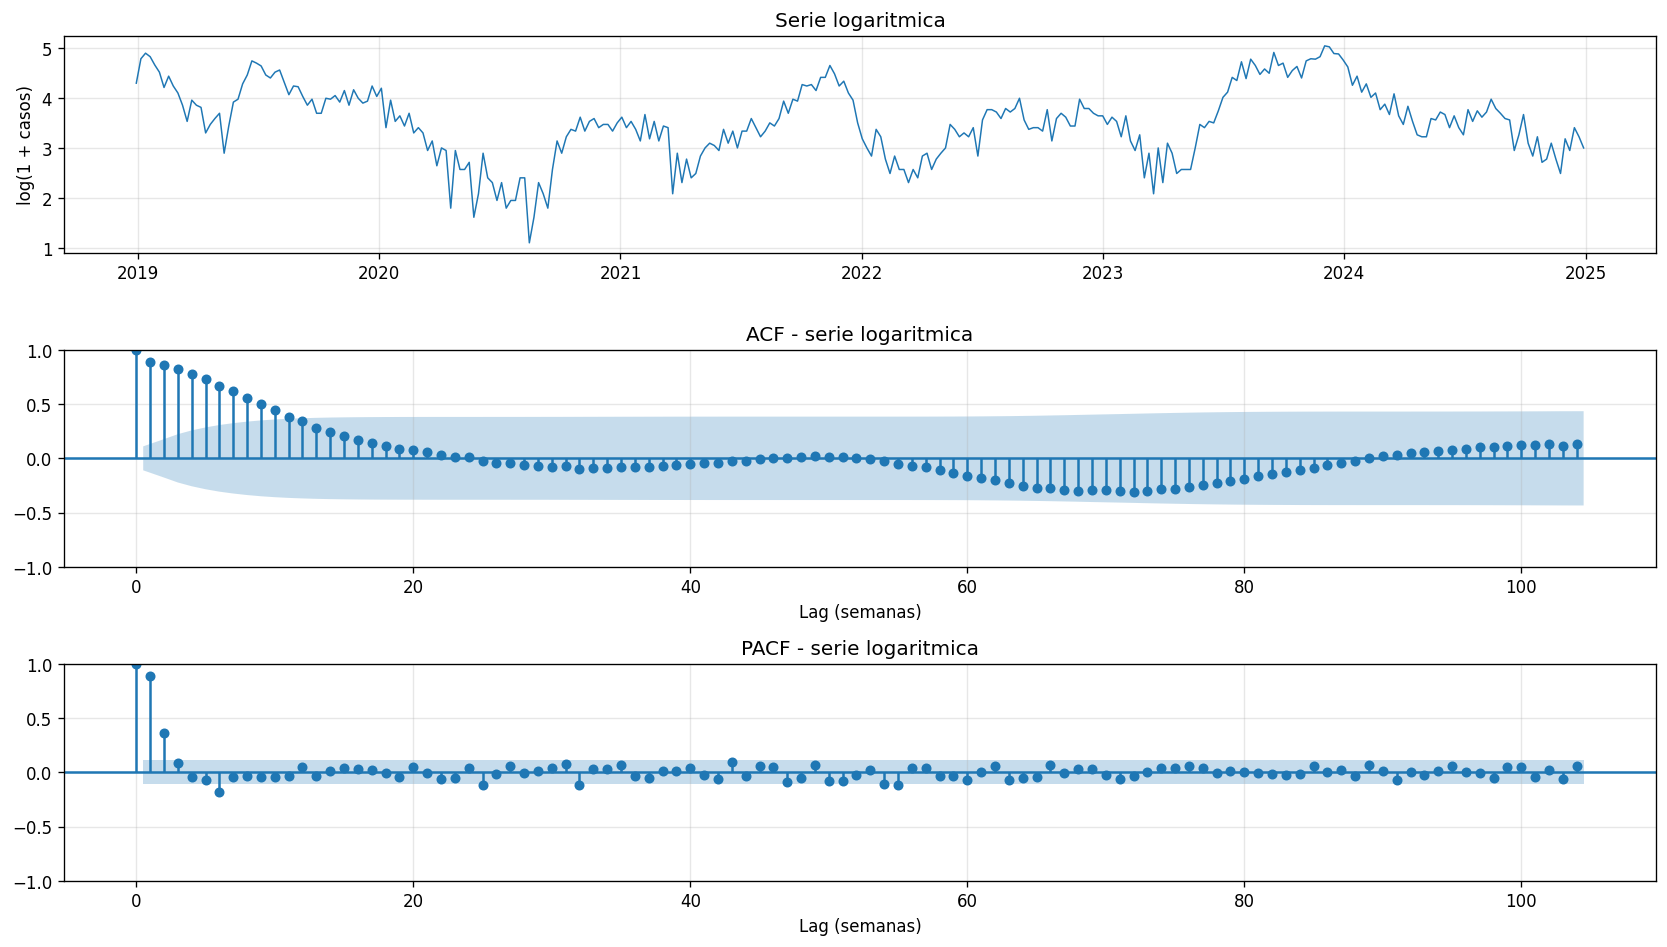

In [144]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# subplot 0 - serie original
axes[0].plot(serie_log.index, serie_log.values, color='#1f77b4', linewidth=0.9)
axes[0].set_ylabel('log(1 + casos)')
axes[0].set_title('Serie logaritmica')
axes[0].grid(alpha=0.3)

# subplot 1 - ACF
plot_acf(serie_log.dropna(), lags=104, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF - serie logaritmica')
axes[1].set_xlabel('Lag (semanas)')
axes[1].grid(alpha=0.3)

# subplot 2 - PACF
plot_pacf(serie_log.dropna(), lags=104, ax=axes[2], alpha=0.05, method='ywm')
axes[2].set_title('PACF - serie logaritmica')
axes[2].set_xlabel('Lag (semanas)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS / 'acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

La PACF presenta dos rezagos significativos (lag 1 cercano a 0.9 y lag 2 alrededor de 0.4) y a partir del lag 3 cae dentro de las bandas de confianza. Este corte tras el segundo rezago es la firma de un componente autorregresivo de orden 1 o 2, por lo que se fija p = [1,2]. La ACF decae de forma gradual sin un corte abrupto, comportamiento consistente con un proceso dominado por la parte autorregresiva; no sugiere un componente de media móvil claro, por lo que se parte de q = 0. Las pruebas de la sección 2.4 ya confirmaron estacionariedad sin diferenciar, de modo que d = 0.

Para los ordenes estacionales, ni ACF ni PACF muestran picos aislados significativos en los multiplos de 52 por lo que P = 0 y Q = 0. El periodo estacional se fija en s = 52, correspondiente al ciclo anual de semanas epidemiologicas, y se incorpora mediante la extension estacional del modelo, es decir SARIMA(p,d,q)(P,D,Q,52), y no mediante un ARIMA simple.

El ciclo anual del dengue de 52 semanas está documentado en la literatura. Zhao et al., trabajando con datos de SIVIGILA en Colombia, incorporan el número ordinal de semana epidemiológica (1 a 52) como predictor explícito para capturar la estacionalidad de la transmisión. Sobre esta base, el componente estacional se incluye en el modelo por justificación epidemiológica y por la evidencia de la descomposición, y no únicamente por el correlograma, cuya capacidad para exhibir estructura estacional es limitada en series cortas con autocorrelación de corto plazo dominante.

Los valores p = [1,2], q = 0, P = 0, Q = 0 y s = 52 constituyen el punto de partida obtenido por identificación manual. En la seccion 4 se usa auto_arima, con d = 0 y D = 0 fijos segun lo confirmado en la seccion 2.4 y s = 52 fijo, para explorar de forma sistematica el espacio de ordenes alrededor de esta propuesta y confirmar o ajustar p, q, P y Q con base en un criterio de informacion (AIC o BIC).

# 3 División temporal train / test

En series de tiempo NO se puede dividir aleatoriamente como en problemas tabulares, porque se filtraría información del futuro hacia el entrenamiento. La división respeta el orden temporal: se entrena con el pasado y se evalúa con el futuro.

Se reservan los años 2019-2023 para entrenamiento y 2024 para prueba. Para la red LSTM se usa además 2023 como conjunto de validación intermedio. Esta sección fija únicamente los cortes temporales sobre la serie departamental cruda; cada familia de modelos construye después su propia representación (las features tabulares se generan dentro de la sección 5 y las secuencias dentro de la sección 6).

Train: 262 sem (2018-2023)
Test : 52 sem (2024)


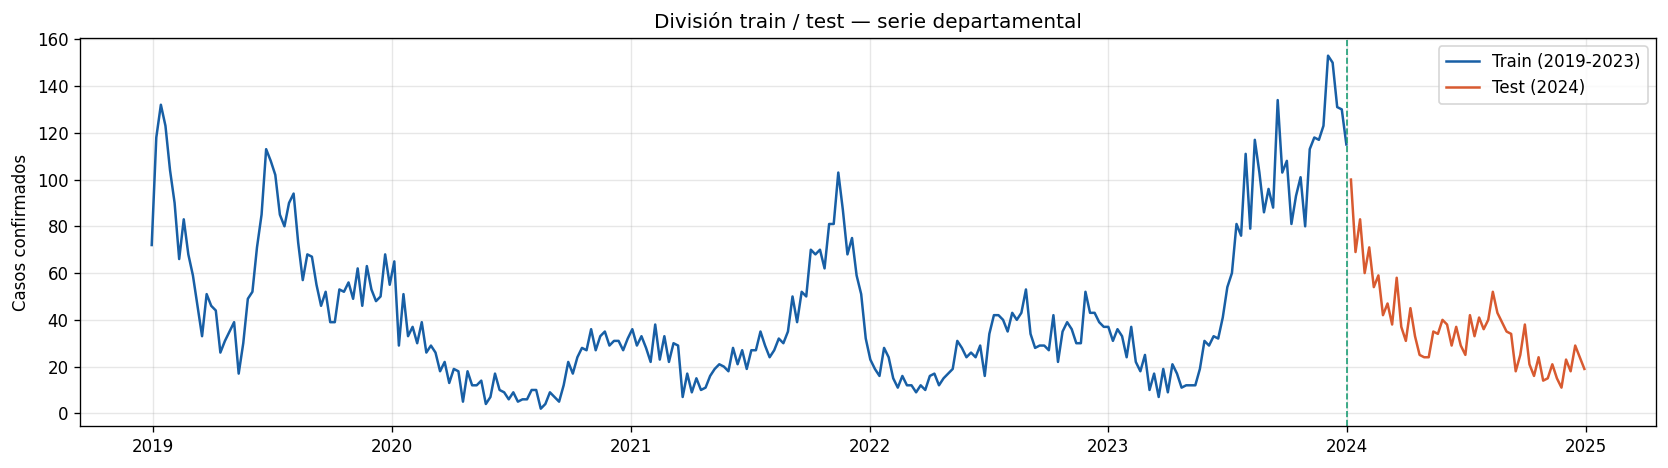

In [146]:
ANIO_TEST = 2024
ANIO_VAL = 2023  

df_train_dep = df_dep[df_dep['fecha'].dt.year < ANIO_TEST].copy()
df_test_dep  = df_dep[df_dep['fecha'].dt.year == ANIO_TEST].copy()

print(f'Train: {len(df_train_dep)} sem ({df_train_dep["fecha"].dt.year.min()}-{df_train_dep["fecha"].dt.year.max()})')
print(f'Test : {len(df_test_dep)} sem ({ANIO_TEST})')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_train_dep['fecha'], df_train_dep['casos'], color='#185FA5', label='Train (2019-2023)')
ax.plot(df_test_dep['fecha'], df_test_dep['casos'], color='#D85A30', label='Test (2024)')
ax.axvline(pd.Timestamp('2024-01-01'), color='#1D9E75', linewidth=1, linestyle='--') #type: ignore
ax.set_ylabel('Casos confirmados')
ax.set_title('División train / test — serie departamental')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

# 4 Modelos estadísticos

Este bloque agrupa los modelos estadísticos clásicos de series de tiempo. La familia ARIMA combina tres componentes: una parte autorregresiva (AR) que usa los valores pasados de la serie, una parte de integración o diferenciación (I) que elimina tendencias para alcanzar estacionariedad, y una parte de media móvil (MA) que usa los errores pasados. Sus extensiones añaden capacidades: SARIMA incorpora una componente estacional con período fijo, y SARIMAX agrega además variables exógenas (la X de eXogenous), predictores externos que influyen en la serie sin formar parte de ella.

A partir del análisis de la sección 2 (estacionariedad confirmada con d = 0, estacionalidad anual respaldada por la descomposición STL y la literatura, y disponibilidad de variables climáticas) se trabaja directamente con SARIMAX como modelo de esta familia, por ser la formulación que aprovecha toda la estructura encontrada. Se complementa con Prophet, un modelo de naturaleza distinta que sirve como comparador.

Todos los modelos de esta sección se entrenan sobre la serie logarítmica serie_log y sus predicciones se revierten a la escala de casos con la transformación inversa np.expm1 antes de calcular las métricas, de modo que los errores se reporten en la unidad interpretable (casos).

## 4.1 Familia ARIMA y extensiones: SARIMAX

La elección de SARIMAX se sustenta en lo encontrado a lo largo del análisis. Las pruebas ADF y KPSS de la sección 2.4 confirmaron que la serie logarítmica es estacionaria sin diferenciar, por lo que se fija d = 0 y D = 0; aplicar diferenciación estacional sobre una serie ya estacionaria la sobre-diferenciaría, deteriorando sus propiedades. La lectura de la PACF fija el orden autorregresivo en p = 2 y la de la ACF sugiere q = 0 como punto de partida. La estacionalidad anual, no visible en el correlograma por las razones expuestas en 2.5 pero clara en la descomposición STL y documentada por Zhao et al. para datos de SIVIGILA en Colombia, se captura con los términos estacionales P y Q sobre un período s = 52, sin recurrir a diferenciación estacional.

El uso de variables exógenas climáticas sigue la formulación de SARIMAX descrita por Chen y Moraga, donde la temperatura y la humedad entran como covariables del modelo de dengue. El clima no actúa de forma instantánea sobre la transmisión: existe un retardo entre la variación climática y el cambio en los casos, asociado al ciclo del vector y al período de incubación. Por ello las variables exógenas se incorporan rezagadas. Estudios sobre variables climáticas semanales sitúan los rezagos relevantes en el rango de 1 a 4 semanas, por lo que se adopta un rezago base de 2 semanas, intermedio dentro de ese rango y consistente con el período de incubación extrínseco del virus en el mosquito.

La selección se separa en dos decisiones independientes. Los órdenes (p, q, P, Q) se eligen con auto_arima minimizando el BIC, con d = 0 y D = 0 fijos por las pruebas de estacionariedad; el análisis del correlograma (PACF con corte en lag 2, ACF de decaimiento gradual) sirve de referencia para acotar los rangos de búsqueda, no para fijar los órdenes a mano. La selección de variables exógenas se hace por experimentación: con los órdenes ya fijados, se registran en MLflow varias configuraciones de SARIMAX que difieren solo en el subconjunto de variables climáticas y se compara su RMSE sobre el conjunto de prueba.

Así el BIC resuelve la estructura temporal y el RMSE resuelve qué clima aporta, sin mezclar ambos criterios ni recurrir a fuerza bruta sobre todas las combinaciones posibles.

### Tratamiento de las variables exógenas

SARIMAX exige que las variables exógenas también sean estacionarias para que sus coeficientes sean válidos. Por ello, antes de incorporarlas, cada una de las cinco variables climáticas (humedad, precipitación, t2m_max, t2m_media, t2m_min) recibe el mismo diagnóstico que se aplicó a la serie de casos: se evalúa la estabilidad de su varianza mediante el coeficiente de variación móvil y se comprueba su estacionariedad con las pruebas ADF y KPSS. La tabla resume ambos diagnósticos para decidir, variable por variable, si requiere alguna transformación o diferenciación antes de entrar al modelo.

        Serie  CV movil var  ADF p-valor          ADF  KPSS p-valor         KPSS  Estacionaria (ambas)
      humedad      0.000969       0.0000 Estacionaria           0.1 Estacionaria                  True
precipitacion      0.162864       0.0002 Estacionaria           0.1 Estacionaria                  True
      t2m_max      0.000087       0.0018 Estacionaria           0.1 Estacionaria                  True
    t2m_media      0.000045       0.0006 Estacionaria           0.1 Estacionaria                  True
      t2m_min      0.000030       0.0039 Estacionaria           0.1 Estacionaria                  True


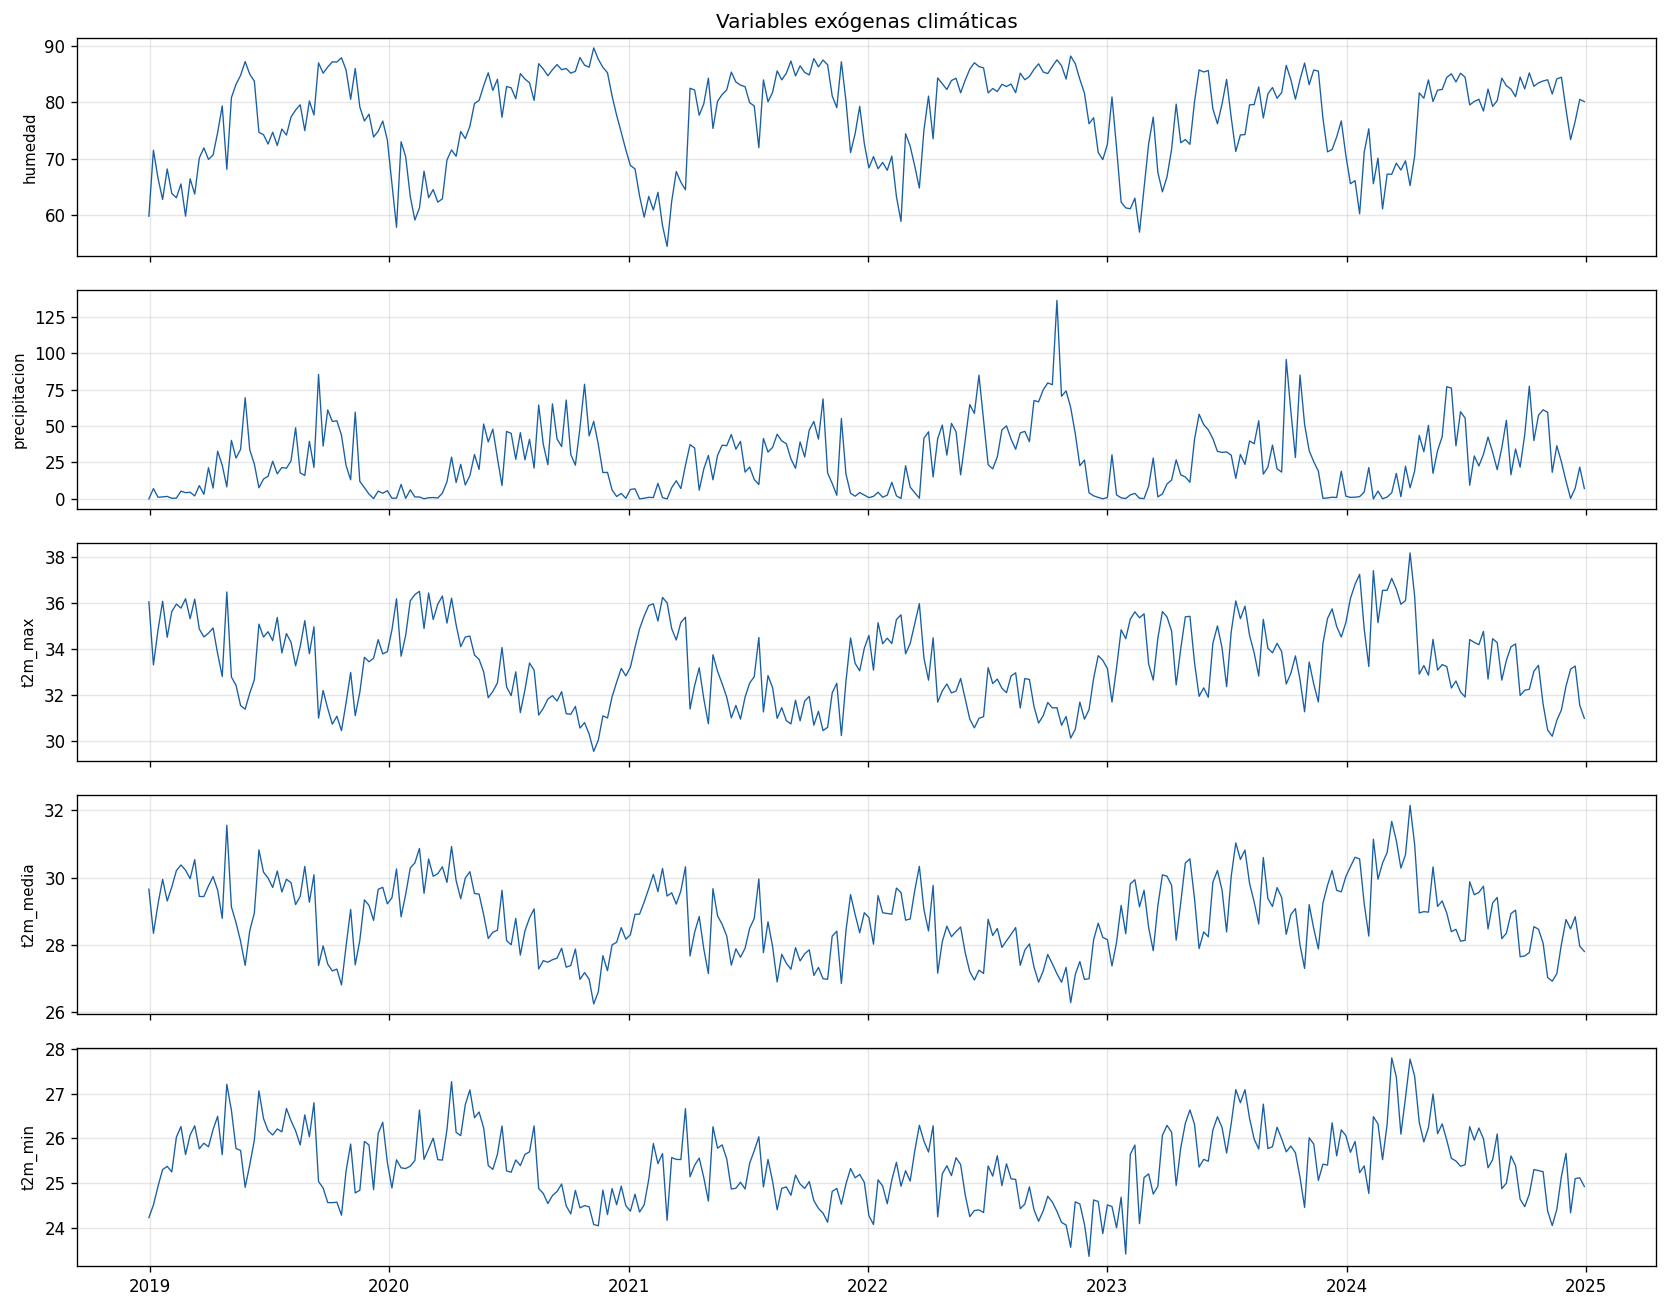

In [147]:
CLIMA_EXOG = ['humedad', 'precipitacion', 't2m_max', 't2m_media', 't2m_min']

serie_exog = df_dep.set_index('fecha')[CLIMA_EXOG]

filas_diag = []
for var in CLIMA_EXOG:
    s = serie_exog[var]
    cv = cv_movil(s)
    fila = evaluar(s, var)
    fila['CV movil var'] = round(float(cv.var()), 6)
    filas_diag.append(fila)

df_diag_exog = pd.DataFrame(filas_diag)[
    ['Serie', 'CV movil var', 'ADF p-valor', 'ADF', 'KPSS p-valor', 'KPSS', 'Estacionaria (ambas)']
]
print(df_diag_exog.to_string(index=False))

# Visualizacion de las cinco series climaticas
fig, axes = plt.subplots(5, 1, figsize=(14, 11), sharex=True)
for ax, var in zip(axes, CLIMA_EXOG):
    ax.plot(serie_exog.index, serie_exog[var], color='#185FA5', linewidth=0.8)
    ax.set_ylabel(var, fontsize=9)
    ax.grid(alpha=0.3)
axes[0].set_title('Variables exógenas climáticas')
plt.tight_layout()
plt.savefig(OUTPUTS / 'exogenas_climaticas.png', dpi=150, bbox_inches='tight')
plt.show()

El coeficiente de variacion movil revela que precipitacion presenta una varianza notablemente menos estable que las demas variables (0.163 frente a valores entre 0.00003 y 0.001 en humedad y las variables de temperatura), un patron similar al observado en la serie de casos antes de su transformacion logaritmica. Por esta razon se aplica log1p a precipitacion, evitando el problema de valores cero presentes en los registros semanales de lluvia. Las cuatro variables restantes muestran varianza estable y ya satisfacen ADF y KPSS sin necesidad de transformacion, por lo que se incorporan al modelo en su escala original.

In [149]:
serie_precip_log = np.log1p(serie_exog['precipitacion'])

cv_precip_log = cv_movil(serie_precip_log)
fila_precip_log = evaluar(serie_precip_log, 'precipitacion_log')
fila_precip_log['CV movil var'] = round(float(cv_precip_log.var()), 6)

df_diag_precip_log = pd.DataFrame([fila_precip_log])[
    ['Serie', 'CV movil var', 'ADF p-valor', 'ADF', 'KPSS p-valor', 'KPSS', 'Estacionaria (ambas)']
]
print(df_diag_precip_log.to_string(index=False))

            Serie  CV movil var  ADF p-valor          ADF  KPSS p-valor         KPSS  Estacionaria (ambas)
precipitacion_log      0.064419       0.0008 Estacionaria           0.1 Estacionaria                  True


La transformacion log1p reduce el coeficiente de variacion movil de precipitacion de 0.163 a 0.064, una disminucion de más de dos veces que confirma la estabilizacion de la varianza. La serie transformada mantiene la estacionariedad segun ADF y KPSS, por lo que precipitacion_log se incorpora al modelo en lugar de la variable original.

### Combinaciones de exógenas a experimentar

Se prueban distintos subconjuntos de variables climáticas para identificar cuál aporta mayor capacidad predictiva, evitando la redundancia entre las tres medidas de temperatura (máxima, media y mínima), que están fuertemente correlacionadas entre sí. Cada configuración se entrena con los mismos órdenes regulares y estacionales y se registra como un experimento independiente en MLflow

El conjunto sin exógenas (equivalente a un SARIMA puro) se incluye como referencia para cuantificar el aporte real del clima.

### Pipeline de datos y función de experimentación

Para no repetir el tratamiento en cada experimento se definen dos funciones. La primera, preparar_datos_sarimax, encapsula el pipeline de datos: construye los rezagos de las variables exógenas indicadas, transforma la serie de casos a escala logarítmica, separa train y test según el corte temporal de la sección 3 y alinea los índices. La segunda, correr_sarimax, recibe la lista de exógenas y los órdenes, llama al pipeline, ajusta el modelo sobre la serie logarítmica, revierte la predicción a escala de casos con np.expm1, calcula las métricas, grafica y registra todo en MLflow. Así cada experimento se reduce a una sola llamada cambiando la lista de exógenas o los órdenes.

In [181]:
LAG_EXOG = 2

def preparar_datos_sarimax(exog_vars, lag=LAG_EXOG, anio_test=ANIO_TEST):
    cols_exog = [f'{v}_lag{lag}' for v in exog_vars]

    base = df_dep.copy()
    for v in exog_vars:
        if v == 'precipitacion_log':
            serie_base = np.log1p(base['precipitacion'])
        else:
            serie_base = base[v]
        base[f'{v}_lag{lag}'] = serie_base.shift(lag) #type: ignore

    base['casos_log'] = np.log1p(base['casos'])
    base['anio'] = base['fecha'].dt.year
    base = base.dropna(subset=cols_exog).set_index('fecha')

    train = base[base['anio'] < anio_test]
    test = base[base['anio'] == anio_test]

    y_train_log = train['casos_log']
    y_test_real = test['casos']
    X_train = train[cols_exog] if cols_exog else None
    X_test = test[cols_exog] if cols_exog else None

    return y_train_log, y_test_real, X_train, X_test, cols_exog


def correr_sarimax(exog_vars, order, seasonal_order, run_name, color='#9467bd'):
    y_train_log, y_test_real, X_train, X_test, cols_exog = preparar_datos_sarimax(exog_vars)

    with mlflow.start_run(run_name=run_name):
        fit = SARIMAX(
            y_train_log,
            exog=X_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)

        pred_log = fit.forecast(steps=len(y_test_real), exog=X_test) #type: ignore
        pred = np.expm1(pred_log).clip(lower=0)
        pred.index = y_test_real.index

        m = compute_metrics(y_test_real, pred)
        mlflow.log_params({
            'order': str(order), 'seasonal_order': str(seasonal_order),
            'exog': ','.join(exog_vars) if exog_vars else 'ninguna',
            'exog_cols': ','.join(cols_exog) if cols_exog else 'ninguna',
            'lag_exog': LAG_EXOG, 'escala_entrenamiento': 'log1p', 'escala': 'departamental',
        })
        mlflow.log_metrics(m)

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(y_train_log.index[-52:], np.expm1(y_train_log).iloc[-52:], #type: ignore
                color='#185FA5', label='Train (último año)')
        ax.plot(y_test_real.index, y_test_real.values, color='black', label='Real 2024') #type: ignore
        ax.plot(pred.index, pred.values, color=color, linestyle='--', label=run_name)
        ax.set_title(f'{run_name} — RMSE={m["RMSE"]} | MAE={m["MAE"]} | MAPE={m["MAPE"]}% | R²={m["R2"]}')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        plt.tight_layout()
        fig_path = OUTPUTS / f'{run_name}.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        mlflow.log_artifact(str(fig_path))
        plt.show()

    print_metrics(run_name, m)
    return m

### Selección de órdenes con auto_arima

En lugar de fijar los órdenes leyendo cada barra del correlograma (lo que en una serie con autocorrelación fuerte lleva a sobreparametrizar, porque muchos cruces de la banda son inercia del proceso y no estructura real), se usa auto_arima para buscar los órdenes que minimizan el BIC.

Se fijan d = 0 y D = 0 según las pruebas de estacionariedad (no se deja que auto_arima los decida, porque ya están confirmados) y se acotan los rangos de p, q, P y Q. La búsqueda se hace sobre la serie logarítmica, sin exógenas, para aislar la selección de la estructura temporal; las exógenas se añaden después en los experimentos. Como la búsqueda con período estacional 52 es costosa, los rangos estacionales se mantienen pequeños.

Una vez ejecutada, se leen los órdenes resultantes y se copian manualmente a las constantes ORDER y SEASONAL_ORDER de la celda de experimentos.

In [191]:
serie_log_train = np.log1p(df_train_dep.set_index('fecha')['casos'])

modelo_auto = auto_arima(
    serie_log_train,
    seasonal=True, m=52,
    d=0, D=0,
    start_p=0, max_p=3,
    start_q=0, max_q=11,
    max_P=1, max_Q=1,
    information_criterion='bic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True,
)

print()
print(modelo_auto.summary())
print()
print('Orden regular (p, d, q):', modelo_auto.order)
print('Orden estacional (P, D, Q, s):', modelo_auto.seasonal_order)

Performing stepwise search to minimize bic
 ARIMA(0,0,0)(1,0,1)[52] intercept   : BIC=inf, Time=4.25 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : BIC=612.602, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : BIC=200.881, Time=3.12 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : BIC=444.851, Time=0.75 sec
 ARIMA(0,0,0)(0,0,0)[52]             : BIC=1419.650, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[52] intercept   : BIC=195.453, Time=0.04 sec
 ARIMA(1,0,0)(0,0,1)[52] intercept   : BIC=200.907, Time=1.12 sec
 ARIMA(1,0,0)(1,0,1)[52] intercept   : BIC=206.589, Time=1.75 sec
 ARIMA(2,0,0)(0,0,0)[52] intercept   : BIC=157.478, Time=0.09 sec
 ARIMA(2,0,0)(1,0,0)[52] intercept   : BIC=162.913, Time=3.93 sec
 ARIMA(2,0,0)(0,0,1)[52] intercept   : BIC=162.927, Time=1.58 sec
 ARIMA(2,0,0)(1,0,1)[52] intercept   : BIC=168.349, Time=2.98 sec
 ARIMA(3,0,0)(0,0,0)[52] intercept   : BIC=160.903, Time=0.14 sec
 ARIMA(2,0,1)(0,0,0)[52] intercept   : BIC=161.218, Time=0.09 sec
 ARIMA(1,0,1)(0,0,0)[52] intercept  

### Experimentos SARIMAX

Con los órdenes ya seleccionados por auto_arima (copiados manualmente en las constantes de abajo), se prueban las distintas combinaciones de variables exógenas. Todas las corridas comparten los mismos órdenes regulares y estacionales, de modo que la única diferencia entre experimentos es el subconjunto de variables climáticas. Cada corrida se registra en MLflow y sus métricas se guardan en resultados_sarimax para comparar por RMSE sobre el conjunto de prueba.

TODO: tras ejecutar auto_arima, copiar sus ordenes en ORDER y SEASONAL_ORDER. Tras correr los experimentos, revisar en MLflow cuál combinación de exógenas minimiza el RMSE y documentar la configuración ganadora.

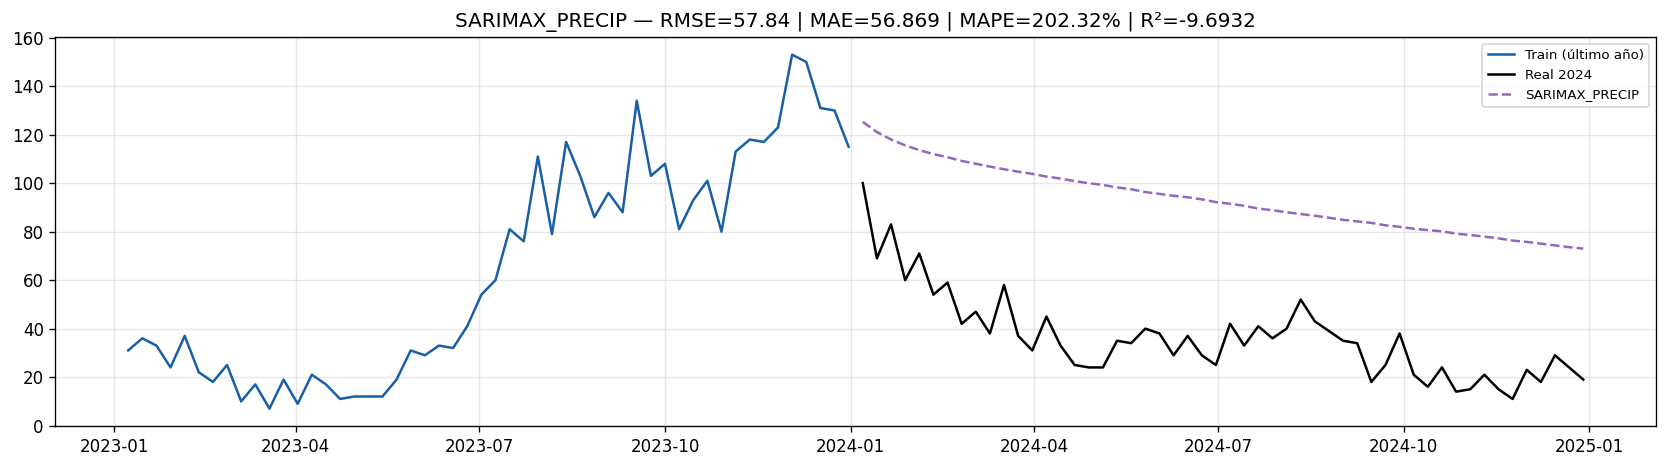

SARIMAX_PRECIP                      RMSE=  57.84 | MAE= 56.87 | MAPE=202.32% | R2=-9.6932


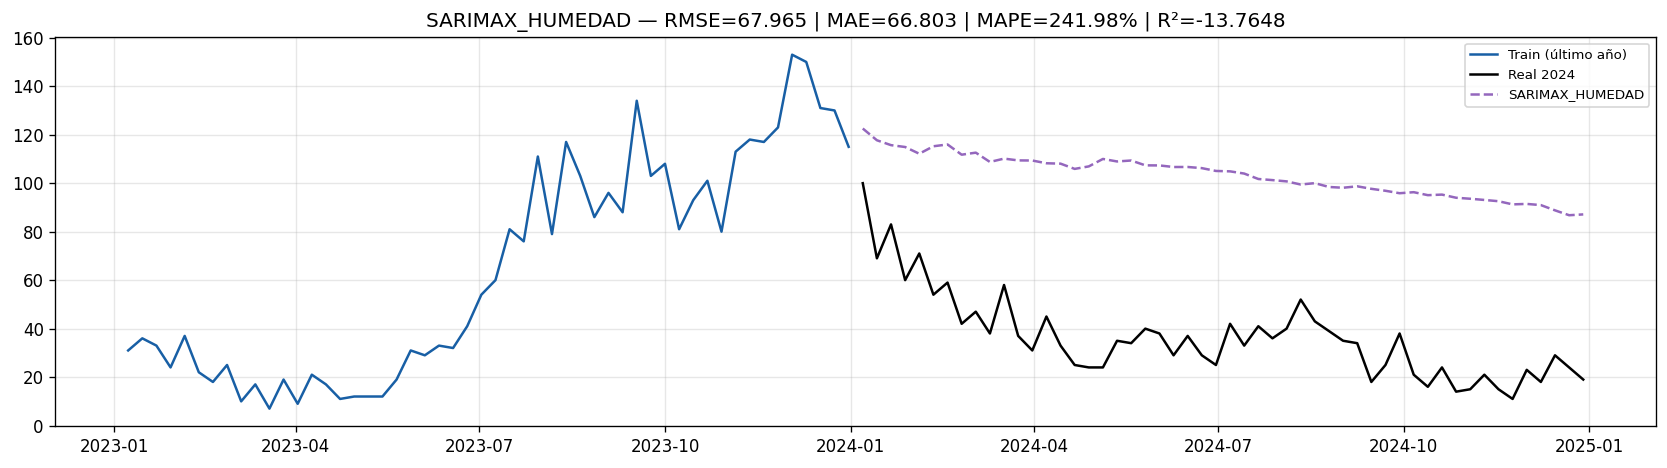

SARIMAX_HUMEDAD                     RMSE=  67.97 | MAE= 66.80 | MAPE=241.98% | R2=-13.7648


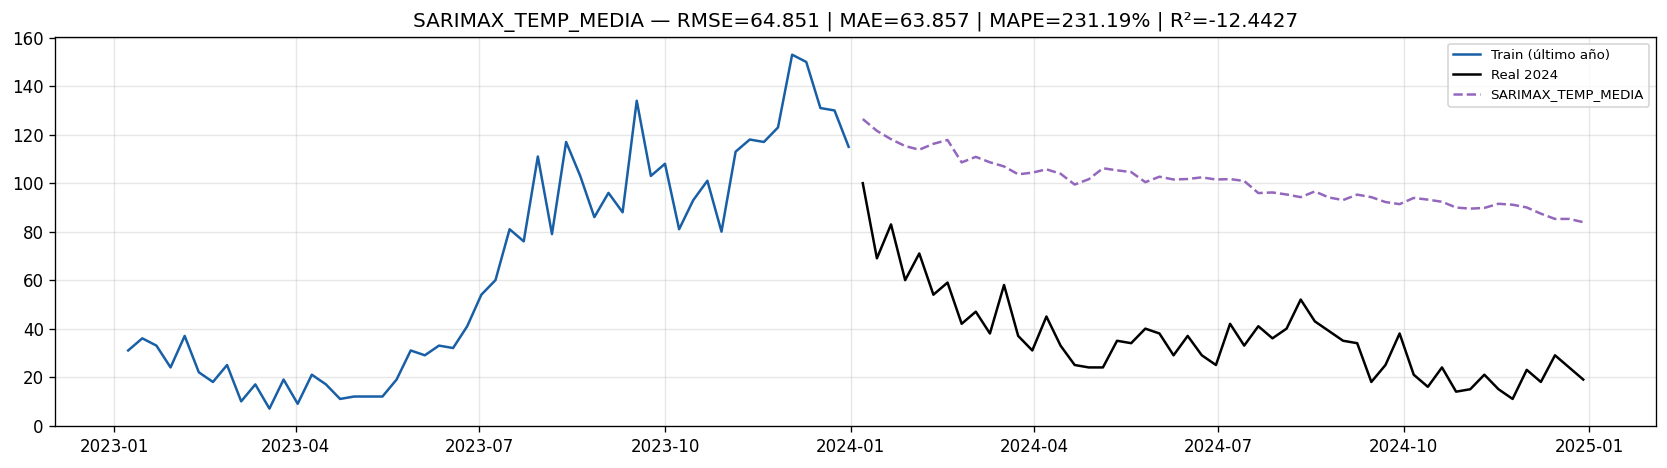

SARIMAX_TEMP_MEDIA                  RMSE=  64.85 | MAE= 63.86 | MAPE=231.19% | R2=-12.4427


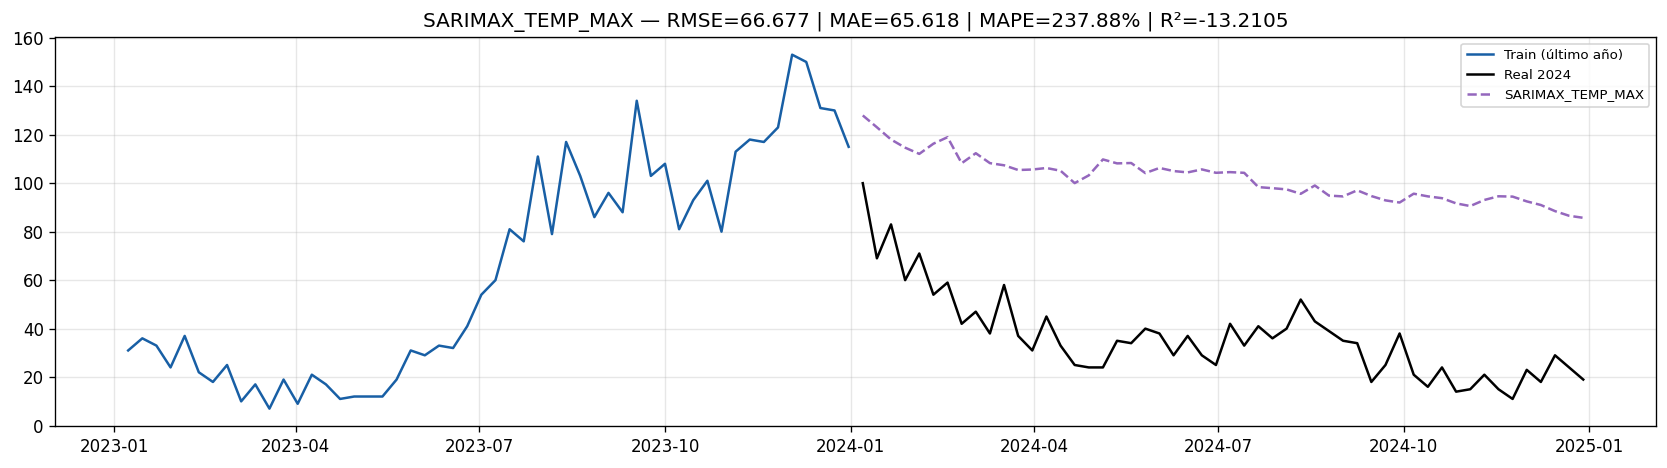

SARIMAX_TEMP_MAX                    RMSE=  66.68 | MAE= 65.62 | MAPE=237.88% | R2=-13.2105


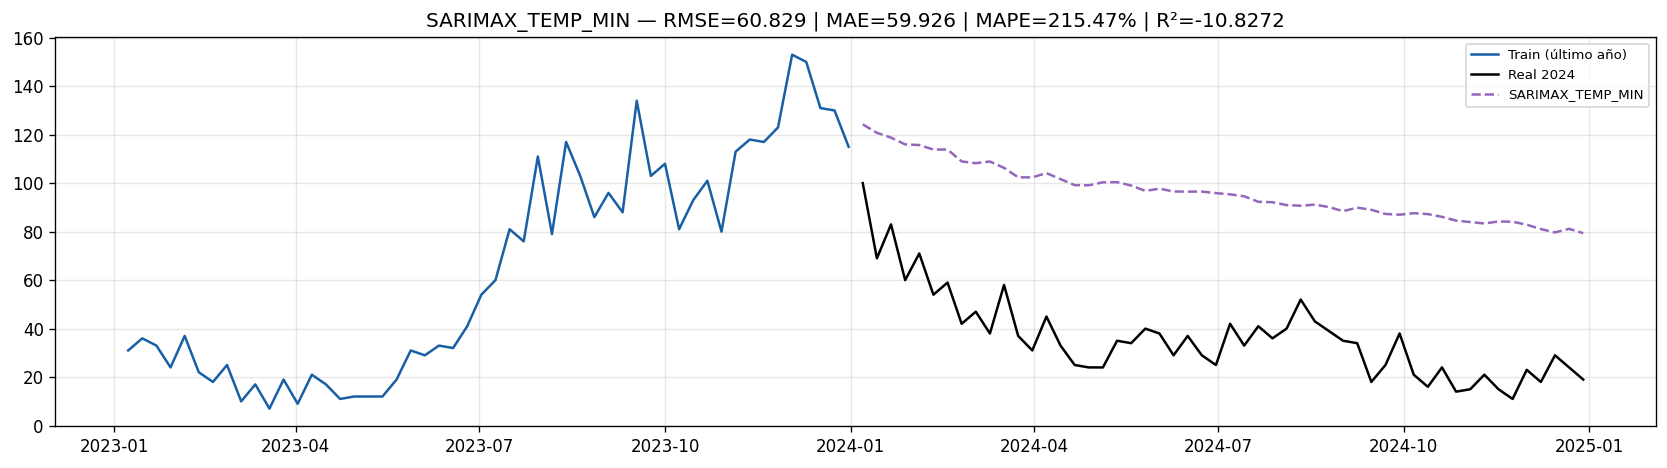

SARIMAX_TEMP_MIN                    RMSE=  60.83 | MAE= 59.93 | MAPE=215.47% | R2=-10.8272


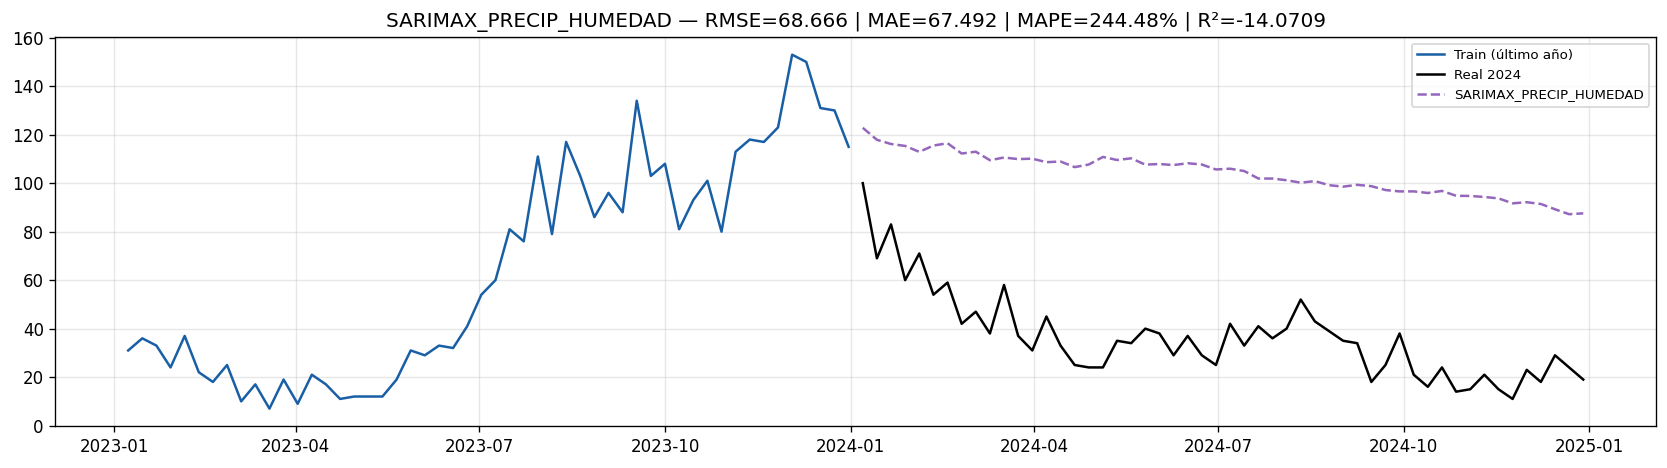

SARIMAX_PRECIP_HUMEDAD              RMSE=  68.67 | MAE= 67.49 | MAPE=244.48% | R2=-14.0709


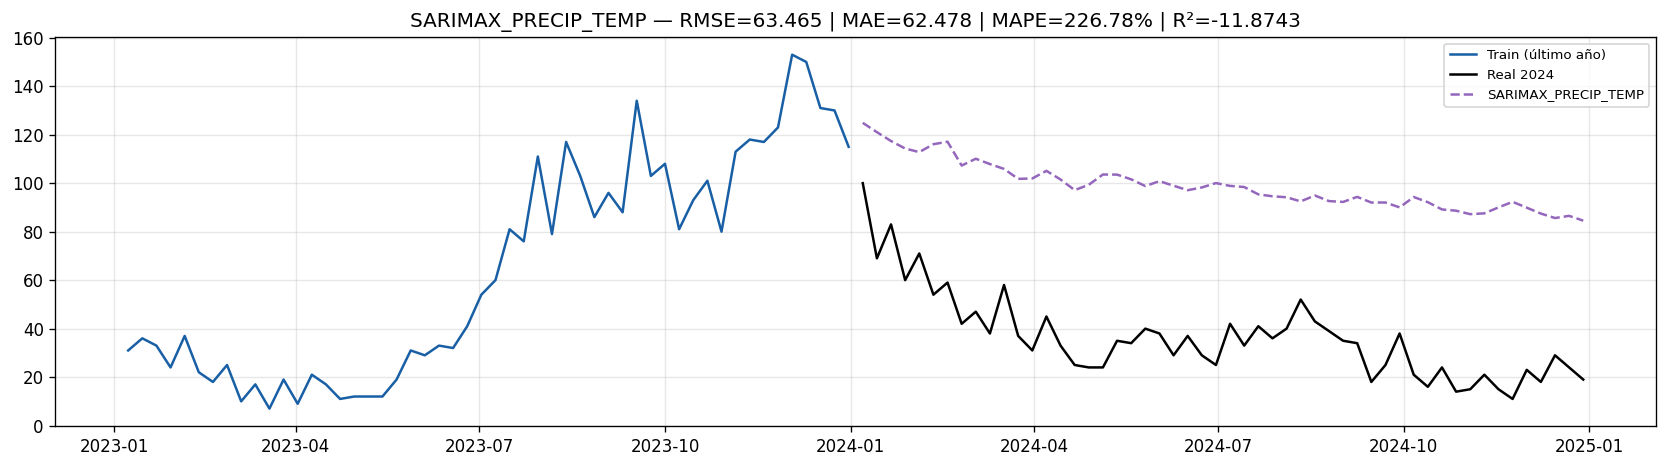

SARIMAX_PRECIP_TEMP                 RMSE=  63.47 | MAE= 62.48 | MAPE=226.78% | R2=-11.8743


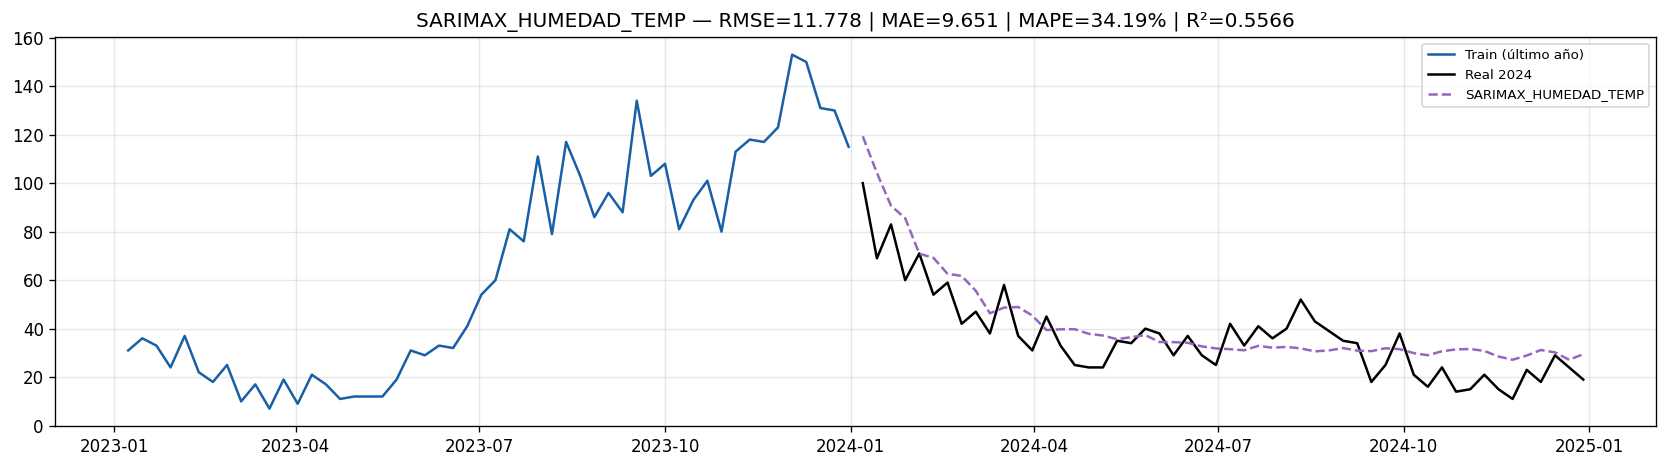

SARIMAX_HUMEDAD_TEMP                RMSE=  11.78 | MAE=  9.65 | MAPE= 34.19% | R2=0.5566


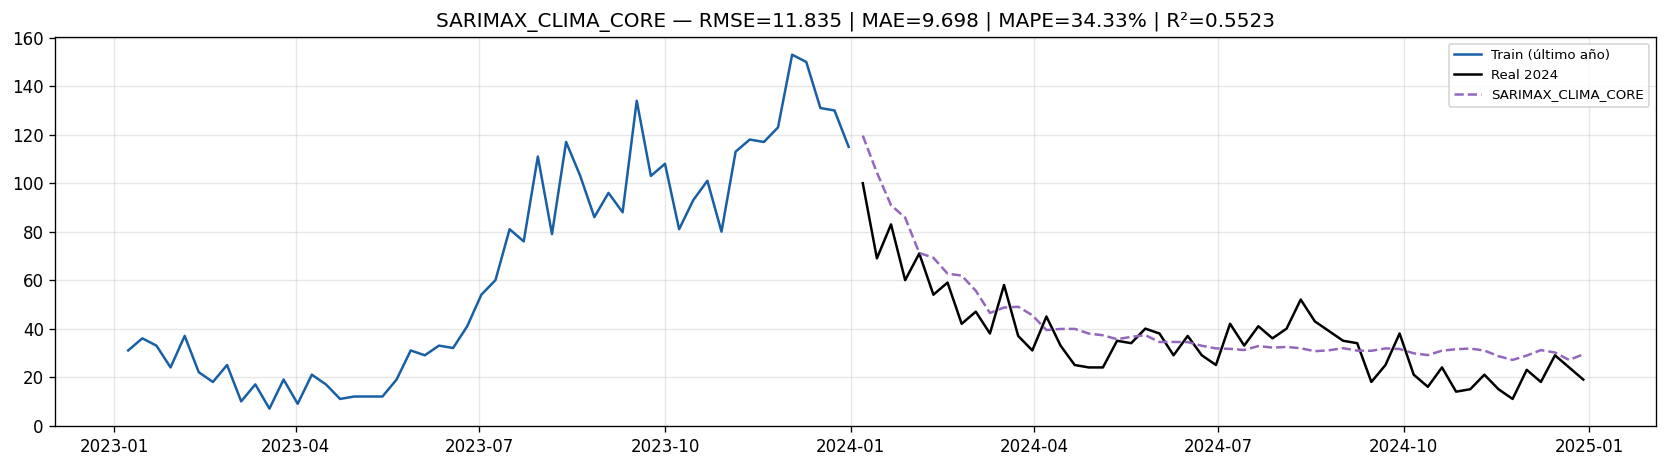

SARIMAX_CLIMA_CORE                  RMSE=  11.84 | MAE=  9.70 | MAPE= 34.33% | R2=0.5523


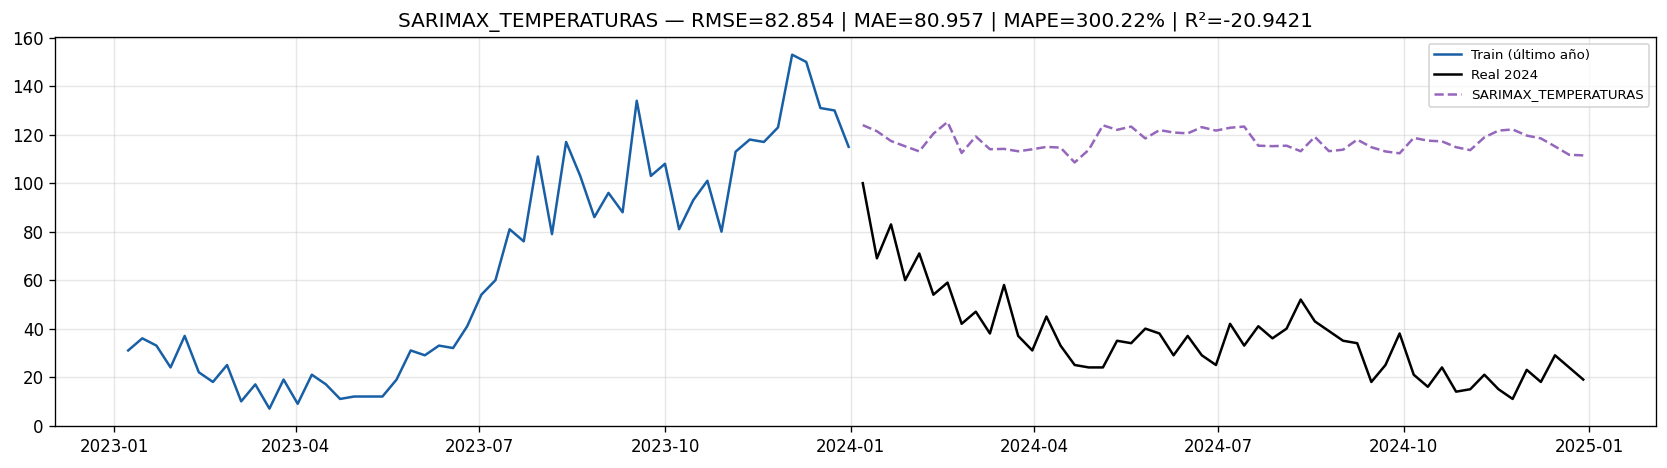

SARIMAX_TEMPERATURAS                RMSE=  82.85 | MAE= 80.96 | MAPE=300.22% | R2=-20.9421

                          RMSE     MAE    MAPE       R2
SARIMAX_HUMEDAD_TEMP    11.778   9.651   34.19   0.5566
SARIMAX_CLIMA_CORE      11.835   9.698   34.33   0.5523
SARIMAX_PRECIP          57.840  56.869  202.32  -9.6932
SARIMAX_TEMP_MIN        60.829  59.926  215.47 -10.8272
SARIMAX_PRECIP_TEMP     63.465  62.478  226.78 -11.8743
SARIMAX_TEMP_MEDIA      64.851  63.857  231.19 -12.4427
SARIMAX_TEMP_MAX        66.677  65.618  237.88 -13.2105
SARIMAX_HUMEDAD         67.965  66.803  241.98 -13.7648
SARIMAX_PRECIP_HUMEDAD  68.666  67.492  244.48 -14.0709
SARIMAX_TEMPERATURAS    82.854  80.957  300.22 -20.9421


In [200]:
ORDER = (2, 0, 2)
SEASONAL_ORDER = (0, 0, 0, 52)

experimentos = [
    (['precipitacion'], 'SARIMAX_PRECIP'),
    (['humedad'], 'SARIMAX_HUMEDAD'),
    (['t2m_media'], 'SARIMAX_TEMP_MEDIA'),
    (['t2m_max'], 'SARIMAX_TEMP_MAX'),
    (['t2m_min'], 'SARIMAX_TEMP_MIN'),

    (['precipitacion', 'humedad'], 'SARIMAX_PRECIP_HUMEDAD'),
    (['precipitacion', 't2m_media'], 'SARIMAX_PRECIP_TEMP'),
    (['humedad', 't2m_media'], 'SARIMAX_HUMEDAD_TEMP'),

    (['precipitacion', 'humedad', 't2m_media'], 'SARIMAX_CLIMA_CORE'),

    (['t2m_min', 't2m_max', 't2m_media'], 'SARIMAX_TEMPERATURAS')
]

resultados_sarimax = {}
for exog_vars, nombre in experimentos:
    resultados_sarimax[nombre] = correr_sarimax(exog_vars, ORDER, SEASONAL_ORDER, nombre)

print()
df_exp = pd.DataFrame(resultados_sarimax).T.sort_values('RMSE')
print(df_exp.to_string())

## 4.2 Prophet

Prophet es un modelo desarrollado por Meta para pronóstico de series con estacionalidad fuerte. A diferencia de SARIMAX, descompone la serie de forma aditiva en tendencia, estacionalidad y efectos de regresores, y es más robusto frente a datos faltantes y valores atípicos. Maneja su propia estacionalidad anual de forma interna, por lo que se entrena en la escala original de casos (no en log) y se incluye con las mismas variables climáticas como regresores, para compararlo con SARIMAX en igualdad de condiciones.

23:10:57 - cmdstanpy - INFO - Chain [1] start processing
23:10:57 - cmdstanpy - INFO - Chain [1] done processing


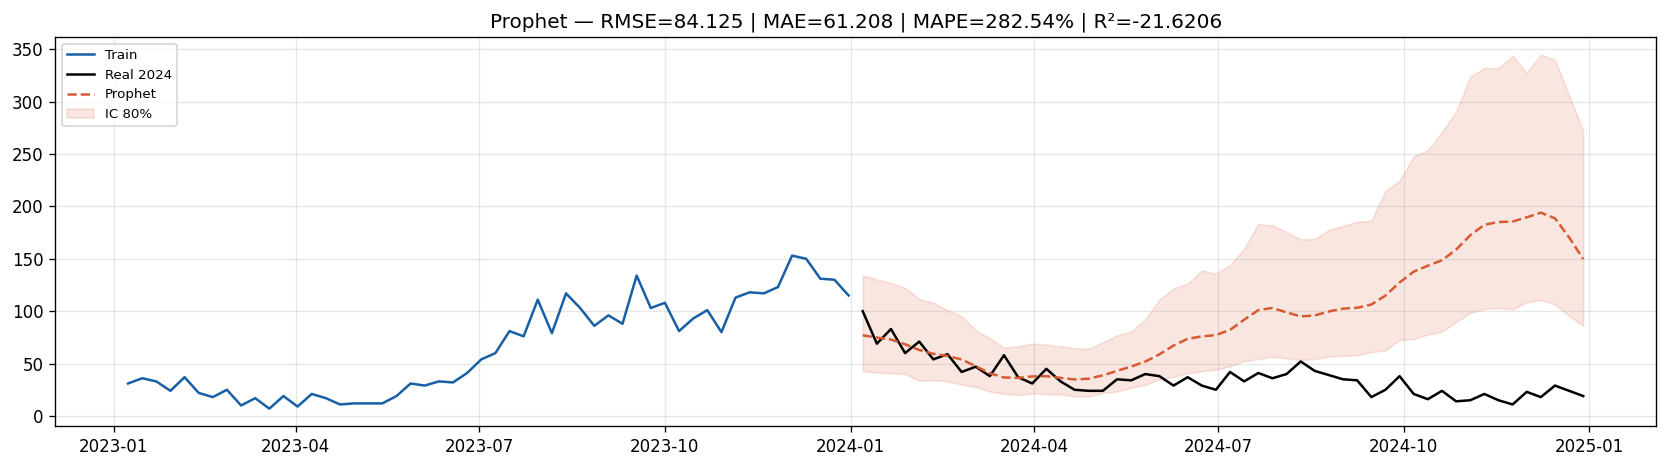

Prophet                             RMSE=  84.12 | MAE= 61.21 | MAPE=282.54% | R2=-21.6206


23:10:59 - cmdstanpy - INFO - Chain [1] start processing
23:10:59 - cmdstanpy - INFO - Chain [1] done processing


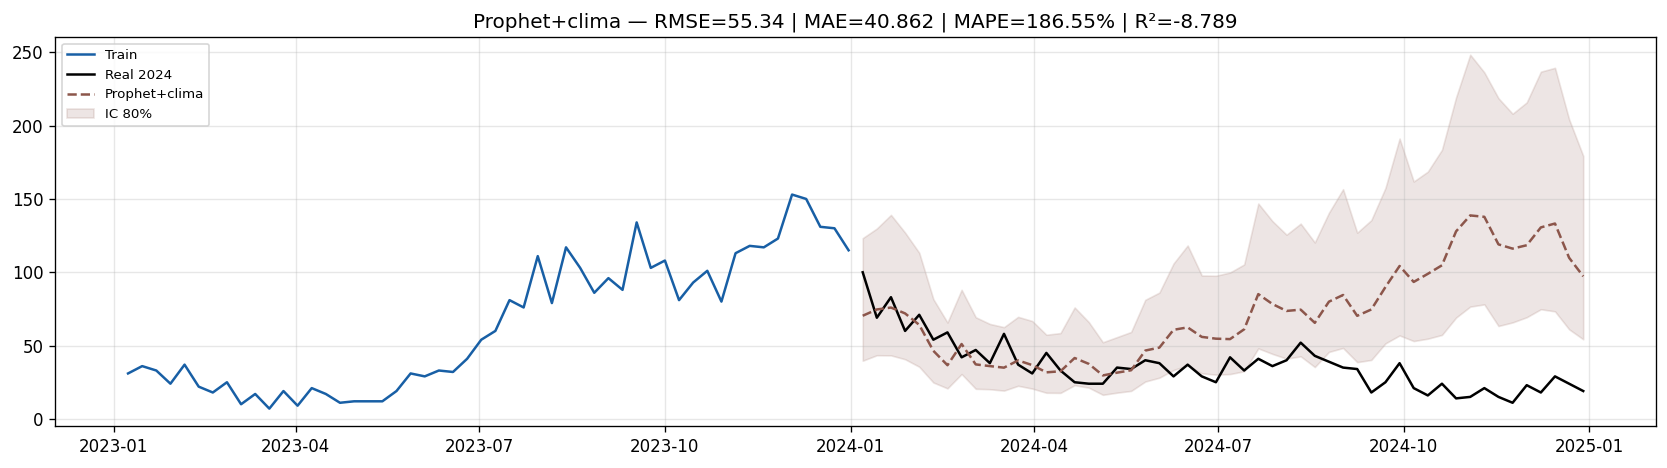

Prophet+clima                       RMSE=  55.34 | MAE= 40.86 | MAPE=186.55% | R2=-8.7890


23:11:01 - cmdstanpy - INFO - Chain [1] start processing
23:11:01 - cmdstanpy - INFO - Chain [1] done processing


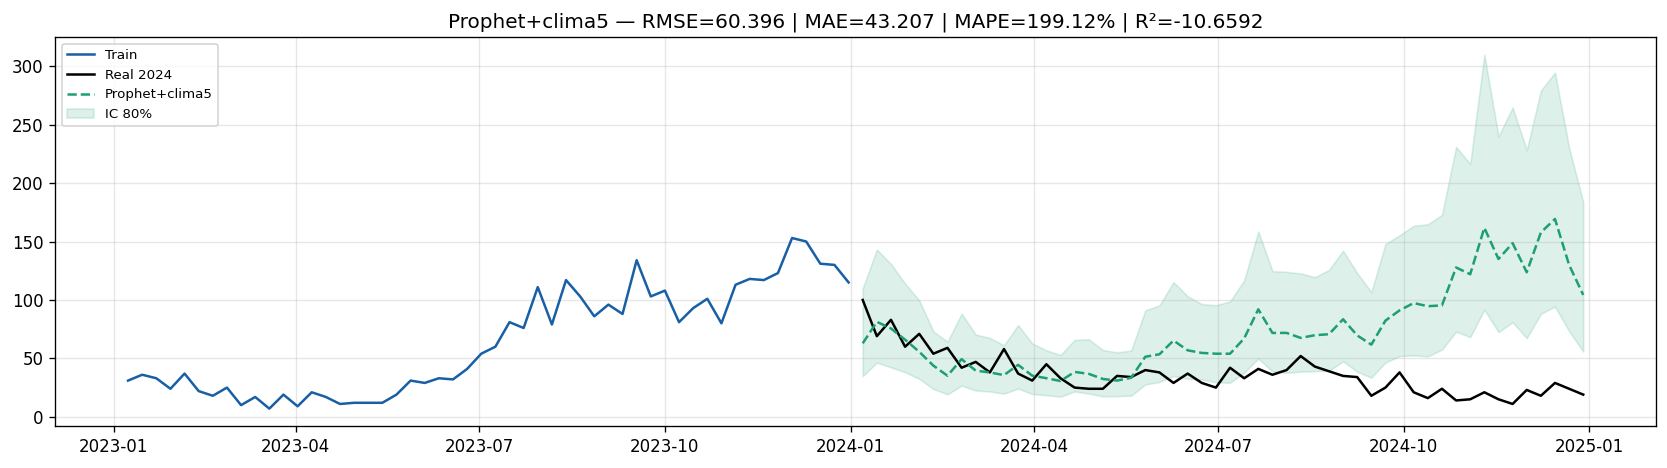

Prophet+clima5                      RMSE=  60.40 | MAE= 43.21 | MAPE=199.12% | R2=-10.6592


In [204]:
PROPHET_EXOG_2 = ['t2m_media', 'humedad']
PROPHET_EXOG_5 = ['humedad', 'precipitacion_log', 't2m_max', 't2m_media', 't2m_min']

# Todas las variables que algun modelo podria usar, rezagadas
TODAS_EXOG = ['humedad', 'precipitacion', 'precipitacion_log', 't2m_max', 't2m_media', 't2m_min']

base_p = df_dep.copy()
base_p['precipitacion_log'] = np.log1p(base_p['precipitacion'])
for v in TODAS_EXOG:
    base_p[f'{v}_lag{LAG_EXOG}'] = base_p[v].shift(LAG_EXOG)
base_p['casos_log'] = np.log1p(base_p['casos'])
base_p['anio'] = base_p['fecha'].dt.year

cols_todas = [f'{v}_lag{LAG_EXOG}' for v in TODAS_EXOG]
base_p = base_p.dropna(subset=cols_todas)

train_p = base_p[base_p['anio'] < ANIO_TEST]
test_p = base_p[base_p['anio'] == ANIO_TEST]


def correr_prophet(exog_vars, run_name, color):
    cols = [f'{v}_lag{LAG_EXOG}' for v in exog_vars]

    df_train = train_p[['fecha', 'casos_log'] + cols].rename(columns={'fecha': 'ds', 'casos_log': 'y'})
    df_test = test_p[['fecha', 'casos'] + cols].rename(columns={'fecha': 'ds', 'casos': 'y'})

    with mlflow.start_run(run_name=run_name):
        m_obj = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        for col in cols:
            m_obj.add_regressor(col)
        m_obj.fit(df_train)

        forecast = m_obj.predict(df_test)
        pred = np.expm1(forecast['yhat']).clip(lower=0).values
        pred_lower = np.expm1(forecast['yhat_lower']).clip(lower=0)
        pred_upper = np.expm1(forecast['yhat_upper']).clip(lower=0)

        m = compute_metrics(df_test['y'], pred)
        mlflow.log_params({
            'yearly_seasonality': True,
            'regressors': ','.join(exog_vars) if exog_vars else 'ninguna',
            'escala_entrenamiento': 'log1p', 'escala': 'departamental',
        })
        mlflow.log_metrics(m)

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(df_train['ds'].iloc[-52:], np.expm1(df_train['y']).iloc[-52:],
                color='#185FA5', label='Train')
        ax.plot(df_test['ds'], df_test['y'], color='black', label='Real 2024')
        ax.plot(forecast['ds'], pred, color=color, linestyle='--', label=run_name)
        ax.fill_between(forecast['ds'], pred_lower, pred_upper, alpha=0.15, color=color, label='IC 80%')
        ax.set_title(f'{run_name} — RMSE={m["RMSE"]} | MAE={m["MAE"]} | MAPE={m["MAPE"]}% | R²={m["R2"]}')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        plt.tight_layout()
        fig_path = OUTPUTS / f'{run_name}.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        mlflow.log_artifact(str(fig_path))
        plt.show()

    print_metrics(run_name, m)
    return m


m_prophet_solo = correr_prophet([], run_name='Prophet', color='#D85A30')
m_prophet_2var = correr_prophet(PROPHET_EXOG_2, run_name='Prophet+clima', color='#8c564b')
m_prophet_5var = correr_prophet(PROPHET_EXOG_5, run_name='Prophet+clima5', color='#1D9E75')

# 5 Gradient Boosting

A diferencia de los modelos estadísticos que reciben solo la serie de casos, estos usan features construidas a partir de la serie (lags, medias móviles, codificación de calendario). El gradient boosting construye muchos árboles de decisión secuencialmente, donde cada árbol corrige los errores del anterior, lo que captura bien las relaciones no lineales entre el clima y los casos. La ingeniería de características es específica de esta familia, por lo que se construye aquí y no antes.

## 5.1 Ingeniería de características (lag features, rolling, clima)

Los modelos de árboles no entienden el tiempo por sí solos: necesitan que la información temporal se exprese como columnas. Se generan lags climáticos de 1 a 4 semanas (el rezago de 2 semanas es relevante porque refleja el período de incubación extrínseco del virus DENV en el mosquito), medias móviles climáticas de 2 y 4 semanas, lags del target de 1 a 4 y 52 semanas (este último captura el mismo período del año anterior), una codificación cíclica de la semana con seno y coseno, y una bandera de temporada lluviosa del Caribe colombiano.

Luego se calcula la correlación con el target, se detectan pares de features redundantes (correlación mayor a 0.95) para descartar información duplicada, y finalmente se genera la división train/test específica de las features tabulares respetando el mismo corte temporal de la sección 3 (la creación de lags antes del split no produce fuga porque cada lag solo usa valores pasados de la propia serie).

In [205]:
CLIMA_VARS = ['humedad', 'precipitacion', 't2m_max', 't2m_media', 't2m_min']
LAGS_CLIMA = [1, 2, 3, 4]
LAGS_TARGET = [1, 2, 3, 4, 52]


def build_features(serie_dep: pd.DataFrame) -> pd.DataFrame:
    # Trabaja sobre la serie departamental (una fila por semana), ya ordenada por fecha.
    out = serie_dep.copy().sort_values('fecha').reset_index(drop=True)
    out['semana_epi'] = out['fecha'].dt.isocalendar().week.astype(int)

    # Lags y medias moviles del clima
    for var in CLIMA_VARS:
        for lag in LAGS_CLIMA:
            out[f'{var}_lag{lag}'] = out[var].shift(lag)
        for win in [2, 4]:
            out[f'{var}_roll{win}'] = out[var].shift(1).rolling(win, min_periods=1).mean()

    # Lags y media movil del target
    for lag in LAGS_TARGET:
        out[f'casos_lag{lag}'] = out['casos'].shift(lag)
    out['casos_roll4'] = out['casos'].shift(1).rolling(4, min_periods=1).mean()

    # Codificacion ciclica de la semana epidemiologica
    out['semana_sin'] = np.sin(2 * np.pi * out['semana_epi'] / 52)
    out['semana_cos'] = np.cos(2 * np.pi * out['semana_epi'] / 52)

    # Temporada lluviosa Caribe colombiano: sem 14-28 (abr-jul) y 36-48 (sep-dic)
    out['temporada_lluviosa'] = (
        out['semana_epi'].between(14, 28) | out['semana_epi'].between(36, 48)
    ).astype(int)

    return out.dropna().reset_index(drop=True)


df_feat = build_features(df_dep)
print(f'Serie departamental con features: {df_feat.shape}')
print(f'Features nuevas: {len(df_feat.columns) - len(df_dep.columns)}')
df_feat.head(3)


Serie departamental con features: (262, 47)
Features nuevas: 40


,fecha,casos,humedad,precipitacion,t2m_max,t2m_media,t2m_min,semana_epi,humedad_lag1,humedad_lag2,...,t2m_min_roll4,casos_lag1,casos_lag2,casos_lag3,casos_lag4,casos_lag52,casos_roll4,semana_sin,semana_cos,temporada_lluviosa
0,2019-12-29,55,73.287033,5.628432,33.886433,29.225828,25.460720,52,76.646172,74.819489,...,25.791194,68.0,50.0,48.0,53.0,72.0,54.75,6.432491e-16,1.000000,0
1,2020-01-05,65,65.516670,0.476751,34.830956,29.404757,24.887386,1,73.287033,76.646172,...,25.693695,55.0,68.0,50.0,48.0,118.0,55.25,1.205367e-01,0.992709,0
2,2020-01-12,29,57.817020,0.532891,36.184288,30.261751,25.517862,2,65.516670,73.287033,...,25.703160,65.0,55.0,68.0,50.0,132.0,59.50,2.393157e-01,0.970942,0


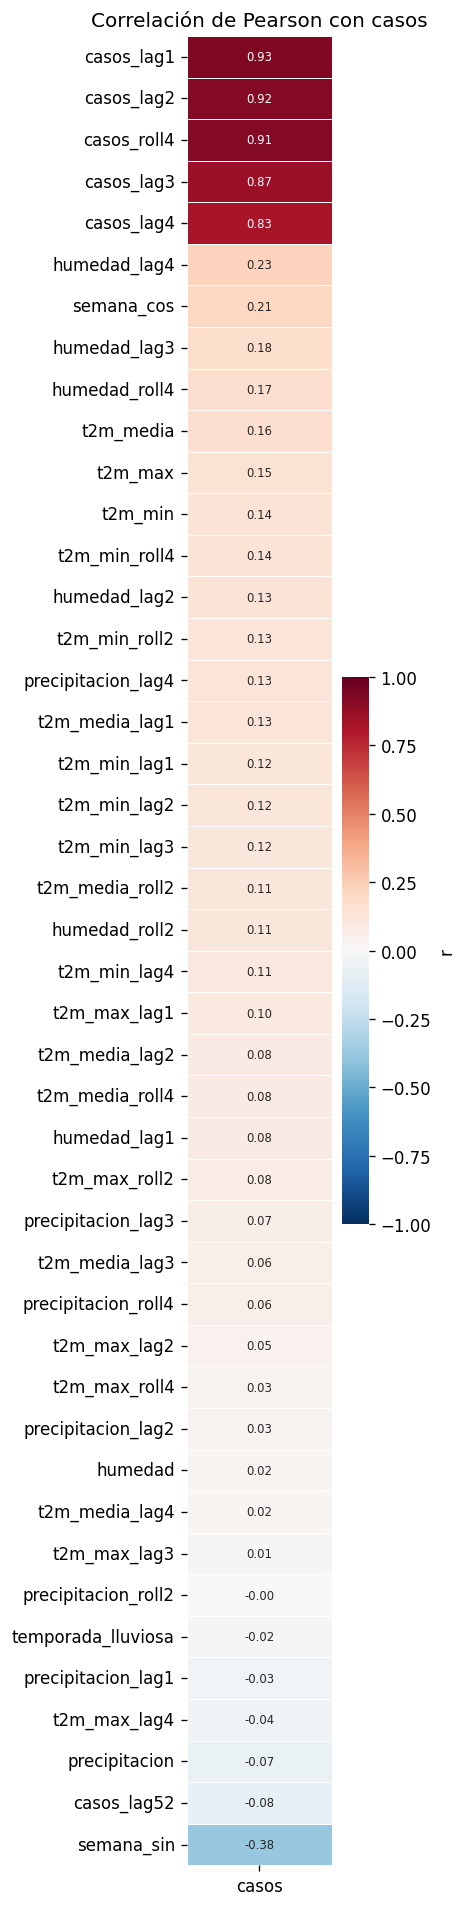

In [206]:
feature_cols = [c for c in df_feat.columns if c not in ['fecha', 'semana_epi']]
corr_target = (
    df_feat[feature_cols].corr()[['casos']]
    .drop('casos')
    .sort_values('casos', ascending=False)
)

fig, ax = plt.subplots(figsize=(4, 16))
sns.heatmap(
    corr_target, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', cbar_kws={'label': 'r'},
    linewidths=0.4, annot_kws={'size': 7},
)
ax.set_title('Correlación de Pearson con casos')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(OUTPUTS / 'correlacion_features.png', dpi=150, bbox_inches='tight')
plt.show()


In [207]:
# Deteccion de features redundantes (multicolinealidad).
# Dos features muy correlacionadas entre si aportan informacion duplicada;
# conservar ambas infla la varianza de los modelos lineales sin aportar señal nueva.
UMBRAL_CORR = 0.95

corr_matrix = df_feat[feature_cols].corr().abs()

# Triangulo superior para no repetir pares (A-B es lo mismo que B-A)
triangulo = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

pares_redundantes = [
    (col, fila, round(triangulo.loc[fila, col], 3))
    for col in triangulo.columns
    for fila in triangulo.index
    if pd.notna(triangulo.loc[fila, col]) and triangulo.loc[fila, col] > UMBRAL_CORR
]

if pares_redundantes:
    print(f'Pares de features con correlacion > {UMBRAL_CORR}:')
    for a, b, r in sorted(pares_redundantes, key=lambda x: -x[2]):
        print(f'  {a:20s} <-> {b:20s} r={r}')
    # se sugiere descartar una de cada par (la segunda), conservando la otra
    a_descartar = sorted(set(b for _, b, _ in pares_redundantes))
    print(f'\nFeatures candidatas a descartar por redundancia: {a_descartar}')
else:
    print(f'No hay pares de features con correlacion > {UMBRAL_CORR}.')
    a_descartar = []


Pares de features con correlacion > 0.95:
  casos_roll4          <-> casos_lag2           r=0.974
  casos_roll4          <-> casos_lag3           r=0.974
  humedad_roll2        <-> humedad_lag1         r=0.962
  humedad_roll2        <-> humedad_lag2         r=0.962
  casos_roll4          <-> casos_lag1           r=0.959
  casos_roll4          <-> casos_lag4           r=0.959
  t2m_media_roll4      <-> t2m_max_roll4        r=0.958
  t2m_media_roll2      <-> t2m_max_roll2        r=0.957
  t2m_media            <-> t2m_max              r=0.955
  humedad_roll4        <-> humedad_roll2        r=0.955
  t2m_media_lag1       <-> t2m_max_lag1         r=0.955
  t2m_media_lag2       <-> t2m_max_lag2         r=0.955
  t2m_media_lag3       <-> t2m_max_lag3         r=0.955
  t2m_media_lag4       <-> t2m_max_lag4         r=0.955

Features candidatas a descartar por redundancia: ['casos_lag1', 'casos_lag2', 'casos_lag3', 'casos_lag4', 'humedad_lag1', 'humedad_lag2', 'humedad_roll2', 't2m_max', 't2m_ma

In [208]:
# Division train/test de las features tabulares, con el mismo corte temporal de la seccion 3
df_feat['anio'] = df_feat['fecha'].dt.year
df_train_feat = df_feat[df_feat['anio'] < ANIO_TEST].copy()
df_test_feat  = df_feat[df_feat['anio'] == ANIO_TEST].copy()

# Features para los modelos de arboles: se excluyen columnas no predictoras
# y las variables climaticas crudas (ya representadas por sus lags).
FEATURE_COLS = [
    c for c in df_feat.columns
    if c not in ['fecha', 'casos', 'anio', 'semana_epi',
                 'humedad', 'precipitacion', 't2m_max', 't2m_media', 't2m_min']
]

X_train = df_train_feat[FEATURE_COLS]
y_train = df_train_feat['casos']
X_test  = df_test_feat[FEATURE_COLS]
y_test  = df_test_feat['casos']

print(f'Train features: {X_train.shape} | Test features: {X_test.shape}')
print(f'Total features: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Train features: (210, 39) | Test features: (52, 39)
Total features: 39
['humedad_lag1', 'humedad_lag2', 'humedad_lag3', 'humedad_lag4', 'humedad_roll2', 'humedad_roll4', 'precipitacion_lag1', 'precipitacion_lag2', 'precipitacion_lag3', 'precipitacion_lag4', 'precipitacion_roll2', 'precipitacion_roll4', 't2m_max_lag1', 't2m_max_lag2', 't2m_max_lag3', 't2m_max_lag4', 't2m_max_roll2', 't2m_max_roll4', 't2m_media_lag1', 't2m_media_lag2', 't2m_media_lag3', 't2m_media_lag4', 't2m_media_roll2', 't2m_media_roll4', 't2m_min_lag1', 't2m_min_lag2', 't2m_min_lag3', 't2m_min_lag4', 't2m_min_roll2', 't2m_min_roll4', 'casos_lag1', 'casos_lag2', 'casos_lag3', 'casos_lag4', 'casos_lag52', 'casos_roll4', 'semana_sin', 'semana_cos', 'temporada_lluviosa']


## 5.2 XGBoost

XGBoost es una implementacion de gradient boosting reconocida por su desempeño en datos tabulares. Construye los arboles optimizando una funcion de perdida con regularizacion, lo que ayuda a controlar el sobreajuste. Recibe todas las features de lags, medias móviles y calendario.

2026/06/11 23:14:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


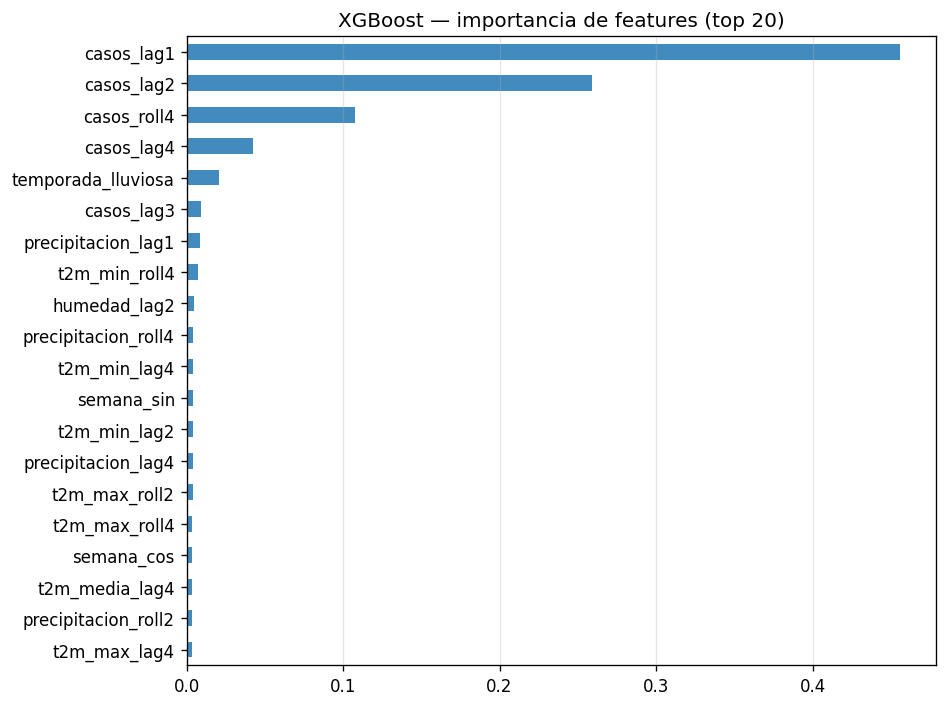

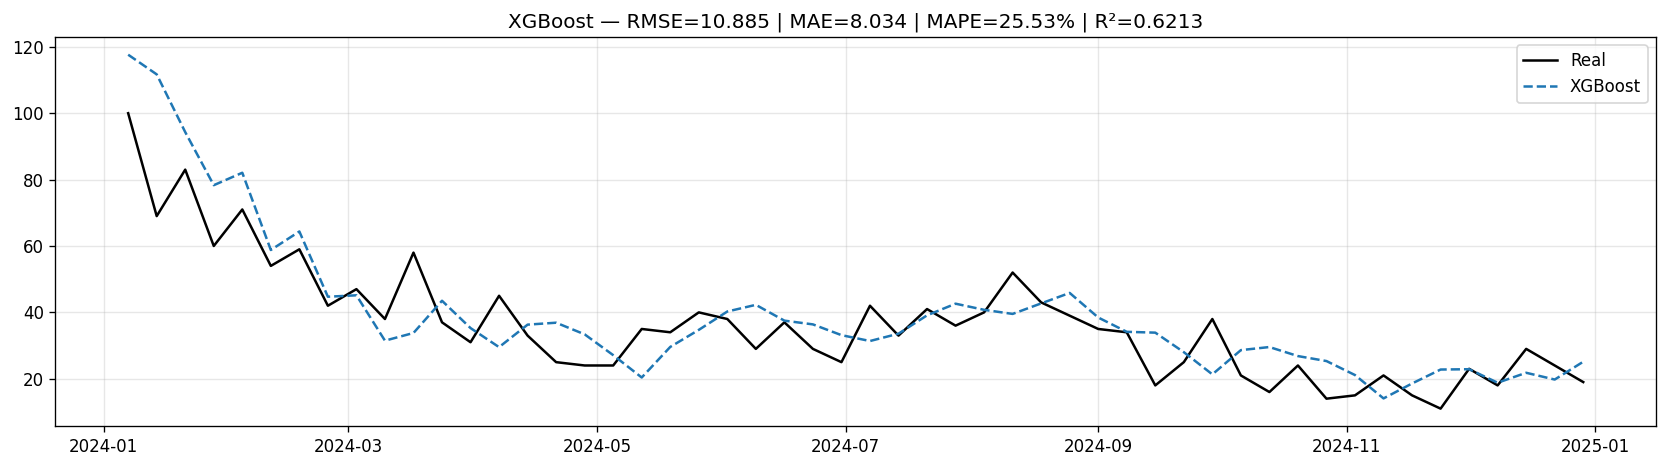

XGBoost-departamental               RMSE=  10.88 | MAE=  8.03 | MAPE= 25.53% | R2=0.6213


In [209]:
with mlflow.start_run(run_name='XGBoost-departamental') as run:
    xgb = XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        random_state=42, n_jobs=-1,
    )
    # No se pasa eval_set con el test para no usar el conjunto de prueba durante el entrenamiento.
    xgb.fit(X_train, y_train)

    pred_xgb = xgb.predict(X_test).clip(min=0)
    m_xgb = compute_metrics(y_test, pred_xgb)

    mlflow.log_params({'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 5,
                       'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3,
                       'escala': 'departamental'})
    mlflow.log_metrics(m_xgb)
    mlflow.xgboost.log_model(xgb, artifact_path='model')

    feat_imp_xgb = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).nlargest(20)
    fig, ax = plt.subplots(figsize=(8, 6))
    feat_imp_xgb.sort_values().plot(kind='barh', ax=ax, color='#1f77b4', alpha=0.85)
    ax.set_title('XGBoost — importancia de features (top 20)')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    imp_path = OUTPUTS / 'xgb_feature_importance.png'
    plt.savefig(imp_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(imp_path))
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df_test_feat['fecha'], y_test.values, color='black', label='Real')
    ax.plot(df_test_feat['fecha'], pred_xgb, color='#1f77b4', linestyle='--', label='XGBoost')
    ax.set_title(f'XGBoost — RMSE={m_xgb["RMSE"]} | MAE={m_xgb["MAE"]} | MAPE={m_xgb["MAPE"]}% | R²={m_xgb["R2"]}')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fig_path = OUTPUTS / 'xgb_pred.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(fig_path))
    plt.show()

print_metrics('XGBoost-departamental', m_xgb)

## 5.3 LightGBM

LightGBM es otra implementacion de gradient boosting, optimizada para ser más rápida y eficiente en memoria que XGBoost, con desempeño comparable. Crece los arboles por hojas (leaf-wise) en lugar de por niveles. Se usa ademas como modelo base para el análisis de interpretabilidad SHAP de la seccion 8.

2026/06/11 23:16:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/11 23:16:34 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


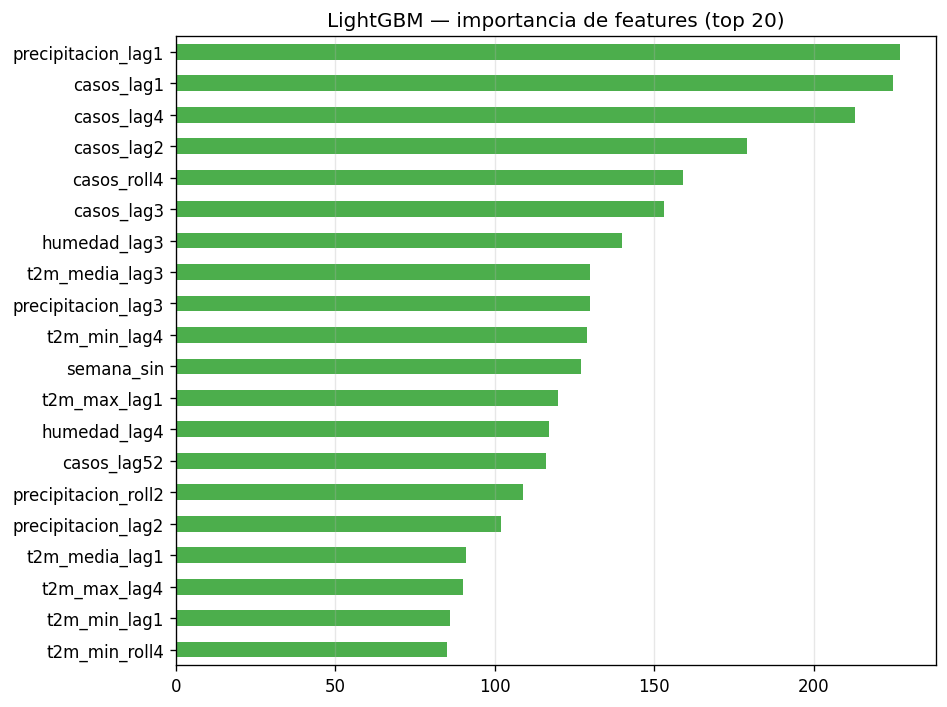

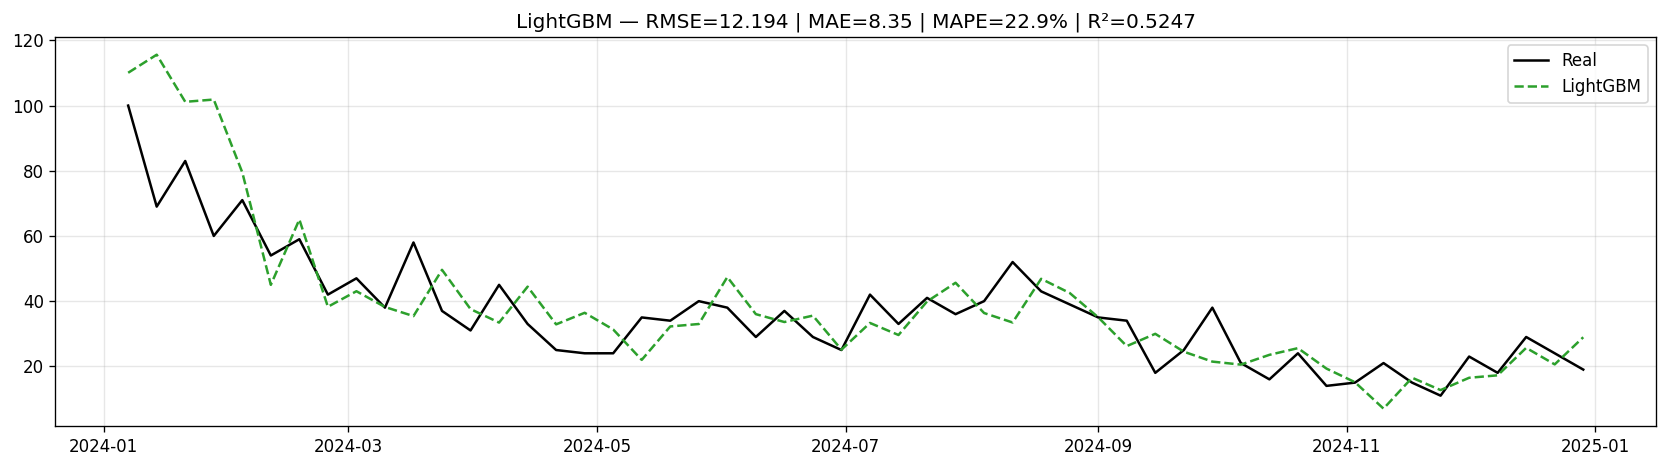

LightGBM-departamental              RMSE=  12.19 | MAE=  8.35 | MAPE= 22.90% | R2=0.5247


In [210]:
with mlflow.start_run(run_name='LightGBM-departamental'):
    lgbm = LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1,
    )
    lgbm.fit(X_train, y_train)

    pred_lgbm = lgbm.predict(X_test).clip(min=0)
    m_lgbm = compute_metrics(y_test, pred_lgbm)

    mlflow.log_params({'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 31,
                       'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8,
                       'escala': 'departamental'})
    mlflow.log_metrics(m_lgbm)
    mlflow.lightgbm.log_model(lgbm, artifact_path='model')

    feat_imp_lgbm = pd.Series(lgbm.feature_importances_, index=FEATURE_COLS).nlargest(20)
    fig, ax = plt.subplots(figsize=(8, 6))
    feat_imp_lgbm.sort_values().plot(kind='barh', ax=ax, color='#2ca02c', alpha=0.85)
    ax.set_title('LightGBM — importancia de features (top 20)')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    imp_path = OUTPUTS / 'lgbm_feature_importance.png'
    plt.savefig(imp_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(imp_path))
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df_test_feat['fecha'], y_test.values, color='black', label='Real')
    ax.plot(df_test_feat['fecha'], pred_lgbm, color='#2ca02c', linestyle='--', label='LightGBM')
    ax.set_title(f'LightGBM — RMSE={m_lgbm["RMSE"]} | MAE={m_lgbm["MAE"]} | MAPE={m_lgbm["MAPE"]}% | R²={m_lgbm["R2"]}')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fig_path = OUTPUTS / 'lgbm_pred.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(fig_path))
    plt.show()

print_metrics('LightGBM-departamental', m_lgbm)

# 6 LSTM

Las redes LSTM (Long Short-Term Memory) son un tipo de red neuronal recurrente diseñada para aprender dependencias temporales largas. A diferencia de los modelos anteriores no necesitan lags manuales: la red recibe una ventana de semanas consecutivas y aprende sola qué información del pasado es relevante. La ventana de entrada es de 12 semanas. La división temporal usa 2019-2022 para entrenar, 2023 para validar y 2024 para probar.

## 6.1 Preparación de secuencias

Las variables se escalan antes de entrenar (las redes neuronales son sensibles a la escala) y el scaler se ajusta solo con datos de entrenamiento para no filtrar información futura. Después se construyen las secuencias deslizantes de 12 semanas y se cortan en train, validación y test.

In [213]:
LSTM_FEATURES = ['casos', 't2m_media', 'precipitacion', 'humedad']
WINDOW = 12

# Dataset departamental indexado por fecha
df_lstm_raw = df_dep.set_index('fecha')[LSTM_FEATURES].copy()
df_lstm_raw['anio_epi'] = df_lstm_raw.index.isocalendar().year.astype(int).values

# Escalado: el scaler se ajusta SOLO con datos de entrenamiento (anios < ANIO_VAL)
# para no filtrar informacion de validacion ni de test al rango aprendido.
scaler = MinMaxScaler()
mask_fit = df_lstm_raw['anio_epi'] < ANIO_VAL
scaler.fit(df_lstm_raw.loc[mask_fit, LSTM_FEATURES])
scaled = scaler.transform(df_lstm_raw[LSTM_FEATURES])
df_scaled = pd.DataFrame(scaled, index=df_lstm_raw.index, columns=LSTM_FEATURES)
df_scaled['anio_epi'] = df_lstm_raw['anio_epi'].values

# Construccion de secuencias
def make_sequences(df_s, window=WINDOW):
    arr = df_s[LSTM_FEATURES].values
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i - window:i])
        y.append(arr[i, 0])
    return np.array(X), np.array(y)

X_all, y_all = make_sequences(df_scaled)

# Indices de corte por anio
idx_list = list(df_scaled.index)
pos_val  = next(i for i, d in enumerate(idx_list) if df_scaled.loc[d, 'anio_epi'] == ANIO_VAL)
pos_test = next(i for i, d in enumerate(idx_list) if df_scaled.loc[d, 'anio_epi'] == ANIO_TEST)

X_tr = X_all[:pos_val - WINDOW]
y_tr = y_all[:pos_val - WINDOW]
X_va = X_all[pos_val - WINDOW:pos_test - WINDOW]
y_va = y_all[pos_val - WINDOW:pos_test - WINDOW]
X_te = X_all[pos_test - WINDOW:]
y_te = y_all[pos_test - WINDOW:]

print(f'Train: {X_tr.shape} | Val: {X_va.shape} | Test: {X_te.shape}')

Train: (198, 12, 4) | Val: (52, 12, 4) | Test: (52, 12, 4)


## 6.2 Arquitectura y entrenamiento

Se define una red de dos capas LSTM apiladas con dropout para regularizar, seguida de capas densas. Se entrena con early stopping sobre la pérdida de validación para detener el entrenamiento cuando deja de mejorar, y se reconstruye la predicción a la escala original de casos para evaluarla.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0302 - val_loss: 0.1512 - learning_rate: 0.0010
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0222 - val_loss: 0.0907 - learning_rate: 0.0010
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0172 - val_loss: 0.0663 - learning_rate: 0.0010
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0175 - val_loss: 0.0795 - learning_rate: 0.0010
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0160 - val_loss: 0.0725 - learning_rate: 0.0010
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0142 - val_loss: 0.0622 - learning_rate: 0.0010
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0153 - val_loss: 0.0602 - learning_rate: 0.0010
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0140 - val_loss: 0.0654 - learning_rate: 0.0010
Epoch 9/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0149 - val_loss: 0.0632 - learning_rate: 0.0010
Epoch 10/2

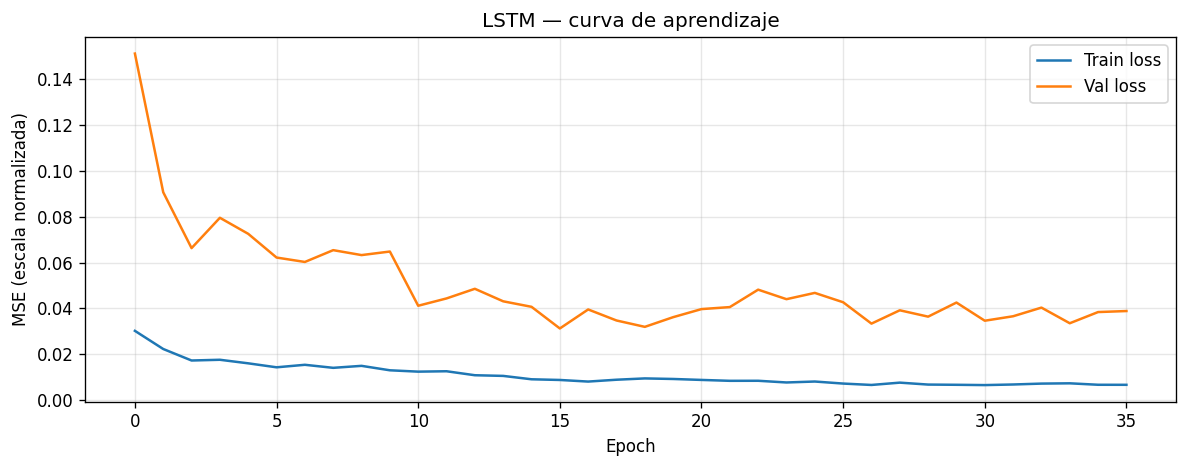

In [214]:
model_lstm = Sequential([
    LSTM(64, input_shape=(WINDOW, len(LSTM_FEATURES)), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1),
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5),
]
history = model_lstm.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=200, batch_size=16,
    callbacks=callbacks, verbose=1,
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], label='Train loss')
ax.plot(history.history['val_loss'], label='Val loss')
ax.set_title('LSTM — curva de aprendizaje')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (escala normalizada)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 413ms/step


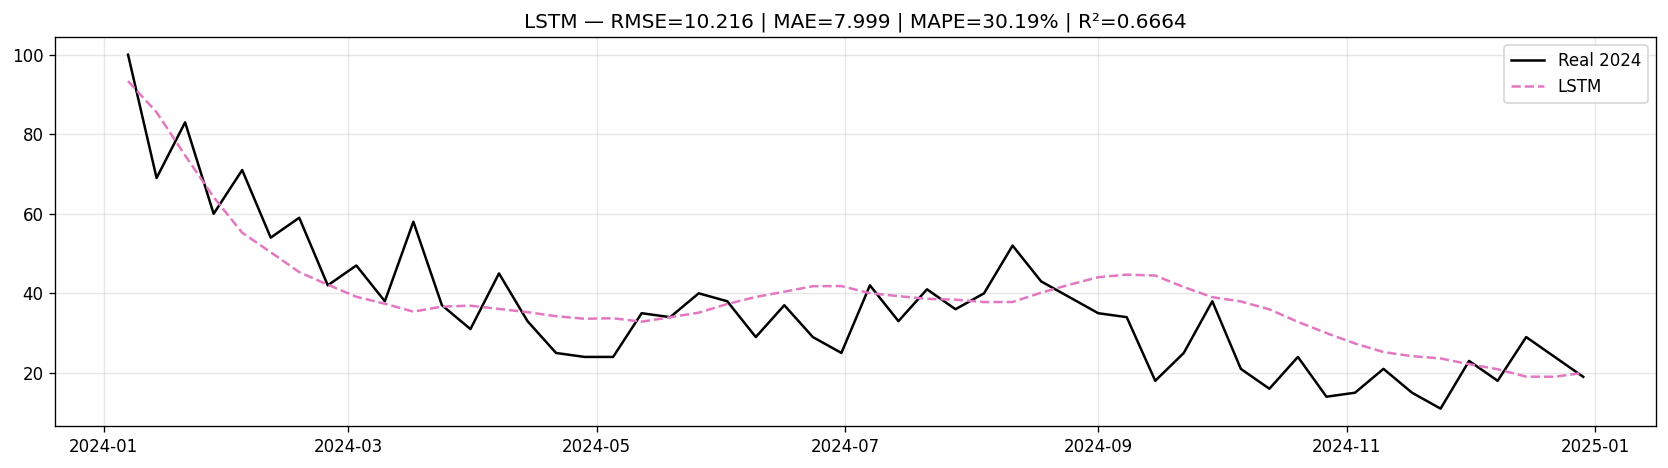

LSTM                                RMSE=  10.22 | MAE=  8.00 | MAPE= 30.19% | R2=0.6664


In [215]:
def inverse_casos(arr_scaled):
    dummy = np.zeros((len(arr_scaled), len(LSTM_FEATURES)))
    dummy[:, 0] = arr_scaled
    return scaler.inverse_transform(dummy)[:, 0].clip(min=0)

with mlflow.start_run(run_name='LSTM'):
    pred_lstm_scaled = model_lstm.predict(X_te).flatten()
    pred_lstm = inverse_casos(pred_lstm_scaled)
    real_lstm = inverse_casos(y_te)

    m_lstm = compute_metrics(real_lstm, pred_lstm)

    mlflow.log_params({
        'window': WINDOW, 'lstm_units_1': 64, 'lstm_units_2': 32,
        'dropout': 0.2, 'batch_size': 16, 'features': str(LSTM_FEATURES),
        'escala': 'departamental',
    })
    mlflow.log_metrics(m_lstm)
    mlflow.log_metric('epochs_trained', len(history.history['loss']))

    fechas_test_lstm = df_scaled.index[pos_test:]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(fechas_test_lstm[:len(real_lstm)], real_lstm, color='black', label='Real 2024')
    ax.plot(fechas_test_lstm[:len(pred_lstm)], pred_lstm, color='#e377c2', linestyle='--', label='LSTM')
    ax.set_title(f'LSTM — RMSE={m_lstm["RMSE"]} | MAE={m_lstm["MAE"]} | MAPE={m_lstm["MAPE"]}% | R²={m_lstm["R2"]}')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fig_path = OUTPUTS / 'lstm_pred.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(fig_path))
    plt.show()

print_metrics('LSTM', m_lstm)

# 7 Comparación de modelos

Todos los modelos operan sobre la serie departamental y se evalúan sobre las mismas semanas de prueba (2024) con las mismas métricas, por lo que la comparación es directa y justa. Las corridas quedan registradas en MLflow bajo el experimento dengue-magdalena.

TODO: tras ejecutar, redactar la conclusion del modelo ganador y su justificacion (no solo por RMSE, sino por el comportamiento durante el brote).

Limitación conocida: este notebook pronostica únicamente a nivel departamental. El pronóstico por municipio requiere un enfoque distinto (modelos de panel o un esquema híbrido para manejar la alta proporción de semanas con cero casos), pendiente de definir.

                        Modelo           Familia        Escala   RMSE    MAE   MAPE       R2
                          LSTM     Deep Learning Departamental 10.216  7.999  30.19   0.6664
               XGBoost + clima Gradient Boosting Departamental 10.885  8.034  25.53   0.6213
SARIMAX (SARIMAX_HUMEDAD_TEMP)       Estadístico Departamental 11.778  9.651  34.19   0.5566
              LightGBM + clima Gradient Boosting Departamental 12.194  8.350  22.90   0.5247
               Prophet + clima       Estadístico Departamental 67.263 59.756 245.27 -13.4612


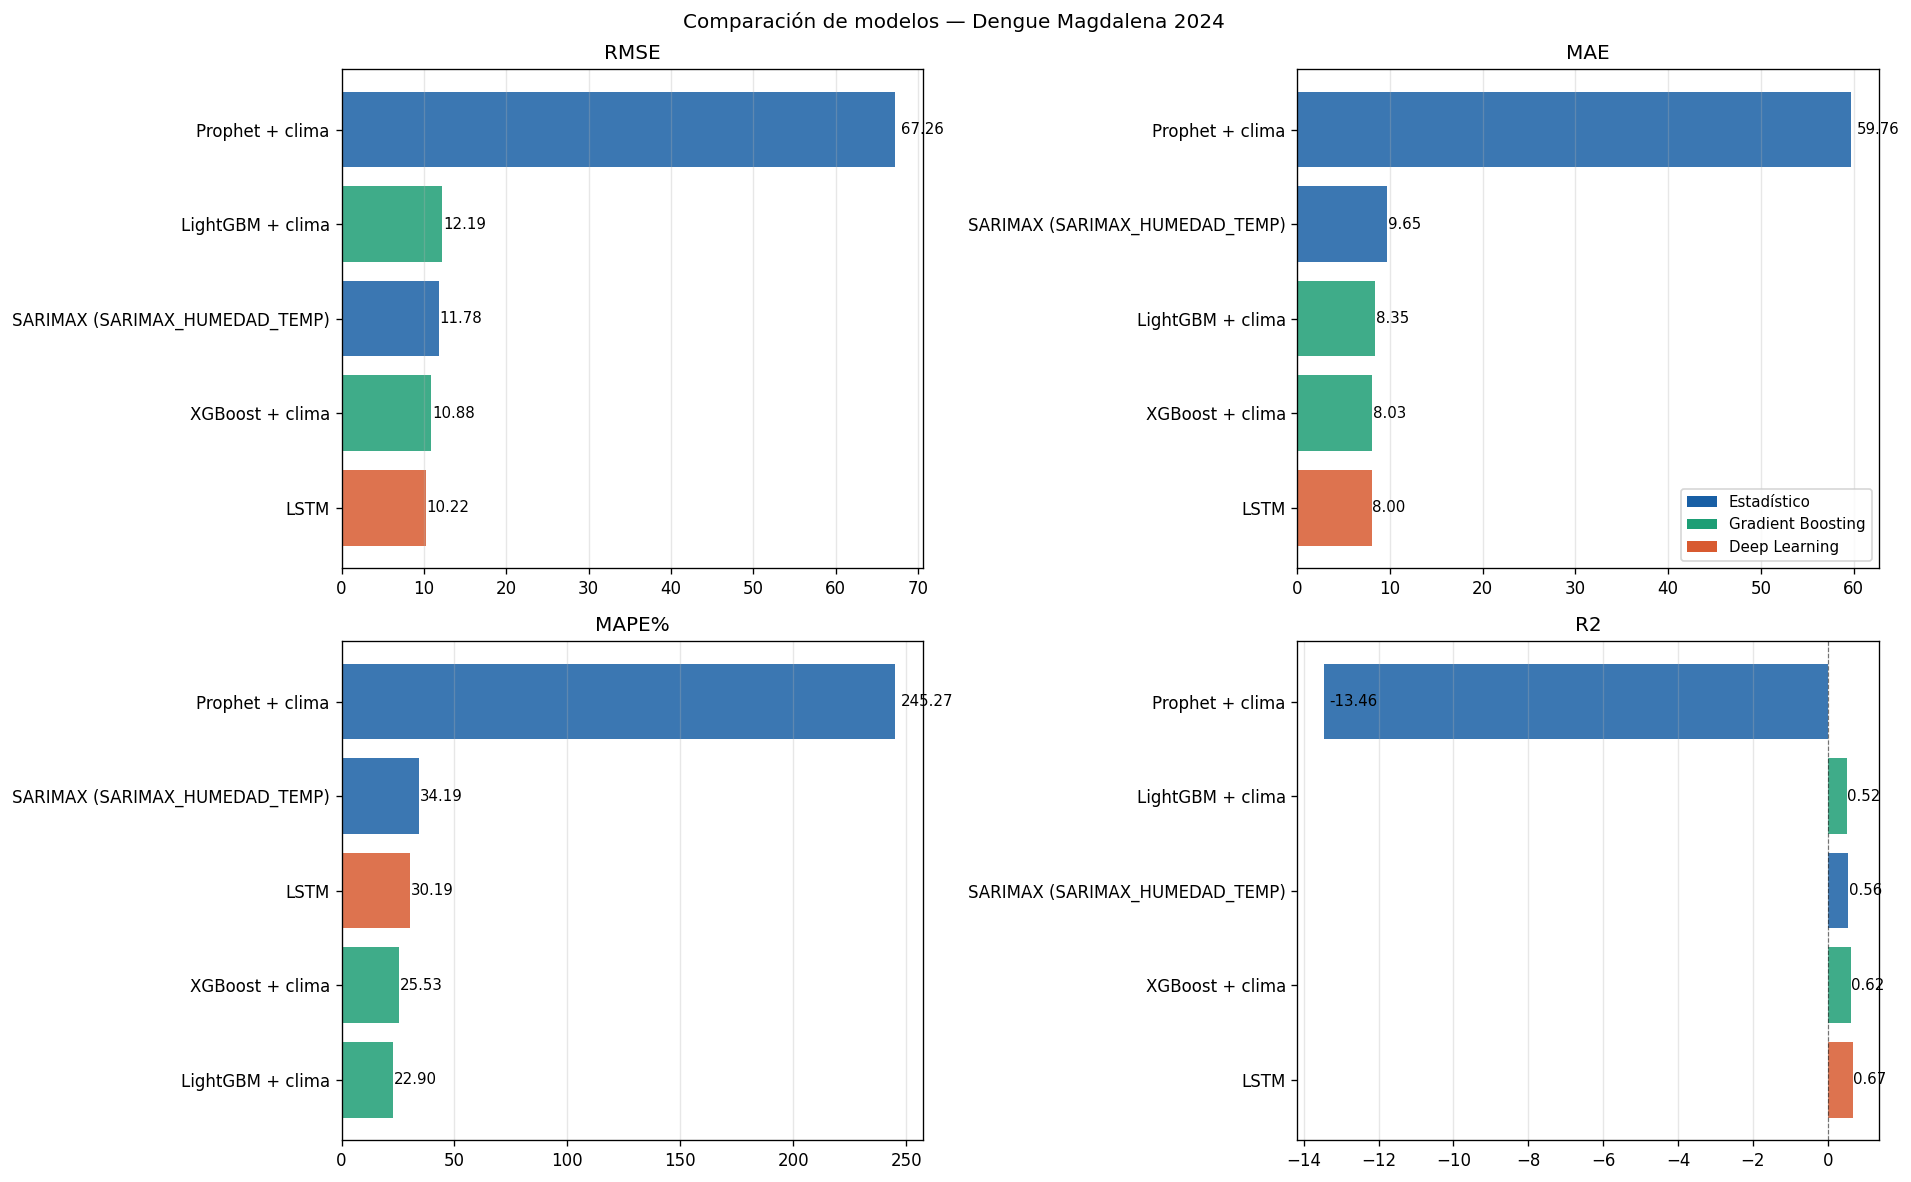

In [216]:
from matplotlib.patches import Patch

# El mejor SARIMAX se toma de los experimentos de la seccion 4.1 (menor RMSE).
mejor_nombre_sarimax = min(resultados_sarimax, key=lambda k: resultados_sarimax[k]['RMSE'])
m_sarimax = resultados_sarimax[mejor_nombre_sarimax]

metricas_modelos = [
    (f'SARIMAX ({mejor_nombre_sarimax})', 'Estadístico',       'Departamental', m_sarimax),
    ('Prophet + clima',                   'Estadístico',       'Departamental', m_prophet),
    ('XGBoost + clima',                   'Gradient Boosting', 'Departamental', m_xgb),
    ('LightGBM + clima',                  'Gradient Boosting', 'Departamental', m_lgbm),
    ('LSTM',                              'Deep Learning',     'Departamental', m_lstm),
]

resultados = pd.DataFrame([
    {'Modelo': nombre, 'Familia': familia, 'Escala': escala, **m}
    for nombre, familia, escala, m in metricas_modelos
]).sort_values('RMSE')

print(resultados[['Modelo', 'Familia', 'Escala', 'RMSE', 'MAE', 'MAPE', 'R2']].to_string(index=False))

colores_familia = {'Estadístico': '#185FA5', 'Gradient Boosting': '#1D9E75', 'Deep Learning': '#D85A30'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, metrica in zip(axes.flat, ['RMSE', 'MAE', 'MAPE', 'R2']):
    df_plot = resultados.sort_values(metrica, ascending=(metrica != 'R2'))
    colors = [colores_familia[f] for f in df_plot['Familia']]
    bars = ax.barh(df_plot['Modelo'], df_plot[metrica], color=colors, alpha=0.85)
    for bar, v in zip(bars, df_plot[metrica]):
        ax.text(v + abs(v) * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{v:.2f}', va='center', fontsize=9)
    if metrica == 'R2':
        ax.axvline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
    suffix = '%' if metrica == 'MAPE' else ''
    ax.set_title(f'{metrica}{suffix}')
    ax.grid(axis='x', alpha=0.3)

leyenda = [Patch(facecolor=c, label=f) for f, c in colores_familia.items()]
axes[0, 1].legend(handles=leyenda, loc='lower right', fontsize=9)

plt.suptitle('Comparación de modelos — Dengue Magdalena 2024', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUTS / 'comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()